# DenseNet121 Dual-Input — Hyperparameter Tuning
### Phases 1-6 + Final Combined Run

DenseNet121 was identified as the best-performing backbone in the architecture comparison. This
notebook tunes it across six phases, run **sequentially and cumulatively**: each phase freezes the
winning value(s) from every phase before it and only varies its own hyperparameter.

| Phase | What varies | Held fixed |
|---|---|---|
| 1 — Learning Rate | `head_lr` / `backbone_lr` (10x ratio kept) | WD, scheduler, augmentation, loss, optimizer = defaults |
| 2 — Weight Decay | `weight_decay` | best LR |
| 3 — Scheduler | `plateau` / `cosine` / `onecycle` | best LR, WD |
| 4 — Augmentation | transform strength | best LR, WD, scheduler |
| 5 — Class Imbalance / Loss | CE / class-weighted CE / focal loss | best LR, WD, scheduler, augmentation |
| 6 — Optimizer | AdamW / Adam / SGD | best LR, WD, scheduler, augmentation, loss |
| Final | — | **all** best values combined |

**How "best" is decided in every phase:** for each candidate value, the run's own best checkpoint
is the epoch with the **lowest validation loss** (same rule used throughout — this determines which
epoch's weights get saved during a run). To then pick the winning *value* across candidates, we
compare each candidate's best-checkpoint **validation accuracy**, with best-checkpoint
**validation loss as a tiebreaker**. This mirrors the selection rule already used for LR/WD in the
original notebook, just applied consistently to every phase.

**Checkpoint policy:** every candidate is trained and evaluated, but immediately after a phase's
winner is chosen, the checkpoint files for every *other* candidate in that phase are deleted from
disk. Only the winning checkpoint per phase (and the final combined run's checkpoint) are kept.


In [2]:
# --- Install / import dependencies ---
import os, time, json, random, warnings, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

try:
    from numpy._core.multiarray import scalar as numpy_scalar
except ImportError:
    from numpy.core.multiarray import scalar as numpy_scalar

safe_globals = [numpy_scalar, np.dtype]
if hasattr(torch.serialization, "add_safe_globals"):
    torch.serialization.add_safe_globals(safe_globals)

print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128 | CUDA available: True


c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- Load dataframes ---
train_df = pd.read_csv("../../dataframes/train_df_final.csv")
val_df   = pd.read_csv("../../dataframes/val_df_final.csv")
test_df  = pd.read_csv("../../dataframes/test_df_final.csv")

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))


train: 2599 val: 328 test: 326


In [4]:
# --- Global configuration ---
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_WORKERS = 4 if os.name != "nt" else 0

HEAD_WARMUP_EPOCHS = 5
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

FULL_PATH_COL = "full image cached path"
CROP_PATH_COL = "cropped image cached path"
LABEL_COL = "pathology"
CLASS_NAMES = ["Benign", "Malignant"]

# Stage 0 baseline defaults — the starting point every phase departs from one variable at a time.
BASELINE = dict(
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4,
    scheduler="plateau",
    augmentation="baseline",
    loss="ce_unweighted",
    optimizer="adamw",
)

RESULTS_DIR = "results"
CKPT_DIR = "checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Data pipeline

Transform *strength* is parameterized (`TRANSFORM_VARIANTS`) so Phase 4 can swap augmentation
without touching anything else. The evaluation transform (val/test) never changes.

In [5]:
# --- Label encoding, transform variants, dataset, loaders ---
def encode_label(raw_label):
    try:
        return int(raw_label)
    except (ValueError, TypeError):
        pass
    text = str(raw_label).strip().upper()
    return 1 if "MALIGNANT" in text else 0


eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Candidate augmentation strengths for Phase 4. "baseline" matches the original notebook exactly.
TRANSFORM_VARIANTS = {
    "none": transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "light": transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "baseline": transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "heavy": transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(25),
        transforms.ColorJitter(brightness=0.25, contrast=0.25),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
}


class DualImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_image = Image.open(row[FULL_PATH_COL]).convert("RGB")
        cropped_image = Image.open(row[CROP_PATH_COL]).convert("RGB")
        full_image = self.transform(full_image)
        cropped_image = self.transform(cropped_image)
        label = torch.tensor(encode_label(row[LABEL_COL]), dtype=torch.long)
        return full_image, cropped_image, label


def make_loaders(train_transform, batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        DualImageDataset(train_df, train_transform), batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        DualImageDataset(val_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    test_loader = DataLoader(
        DualImageDataset(test_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    return train_loader, val_loader, test_loader


# Default loaders (Phases 1-3 use these; Phase 4 rebuilds train_loader per augmentation variant)
train_loader, val_loader, test_loader = make_loaders(TRANSFORM_VARIANTS[BASELINE["augmentation"]])


In [6]:
# --- DenseNet121 dual-input model (best architecture from the comparison notebook) ---
def build_densenet_backbone():
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    base = models.densenet121(weights=weights)
    feature_extractor = nn.Sequential(
        base.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1)),
    )
    return feature_extractor, 1024


class DualInputDenseNet(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.full_extractor, feat_dim_full = build_densenet_backbone()
        self.crop_extractor, feat_dim_crop = build_densenet_backbone()
        combined_dim = feat_dim_full + feat_dim_crop
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, full_image, cropped_image):
        full_feat = torch.flatten(self.full_extractor(full_image), 1)
        crop_feat = torch.flatten(self.crop_extractor(cropped_image), 1)
        combined = torch.cat([full_feat, crop_feat], dim=1)
        return self.classifier(combined)

    def set_backbones_trainable(self, trainable: bool):
        for extractor in (self.full_extractor, self.crop_extractor):
            for p in extractor.parameters():
                p.requires_grad = trainable
            extractor.train(trainable)


In [7]:
# --- Loss function variants (Phase 5) ---
class FocalLoss(nn.Module):
    """Standard multi-class focal loss (Lin et al., 2017), reduces to weighted CE with gamma=0."""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def compute_class_weights():
    labels = train_df[LABEL_COL].apply(encode_label)
    counts = labels.value_counts().sort_index()
    total = counts.sum()
    return torch.tensor([total / (2 * counts[0]), total / (2 * counts[1])], dtype=torch.float32)


def build_loss(name):
    if name == "ce_unweighted":
        return nn.CrossEntropyLoss()
    if name == "ce_class_weighted":
        return nn.CrossEntropyLoss(weight=compute_class_weights().to(DEVICE))
    if name == "focal_loss":
        return FocalLoss(gamma=2.0)
    raise ValueError(f"Unknown loss variant: {name}")


# --- Optimizer variants (Phase 6) ---
def build_optimizer(name, param_groups, weight_decay):
    if name == "adamw":
        return optim.AdamW(param_groups, weight_decay=weight_decay)
    if name == "adam":
        return optim.Adam(param_groups, weight_decay=weight_decay)
    if name == "sgd":
        return optim.SGD(param_groups, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer variant: {name}")


# --- Scheduler variants (Phase 3) ---
def build_scheduler(name, optimizer, steps_per_epoch=None, total_epochs=None):
    if name == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5), "epoch"
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_epochs, 1)), "epoch"
    if name == "onecycle":
        max_lrs = [g["lr"] for g in optimizer.param_groups]
        sched = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs, steps_per_epoch=steps_per_epoch, epochs=total_epochs,
        )
        return sched, "batch"
    raise ValueError(f"Unknown scheduler: {name}")


In [8]:
# --- Metrics + epoch runner ---
def compute_metrics(labels, preds, probs):
    acc = accuracy_score(labels, preds)
    sensitivity = recall_score(labels, preds, pos_label=1, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    f1 = f1_score(labels, preds, zero_division=0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {"accuracy": acc, "sensitivity": sensitivity, "specificity": specificity,
            "f1": f1, "roc_auc": auc}


def run_epoch(model, loader, device, criterion, optimizer=None, scaler=None, use_amp=False, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    grad_context = torch.enable_grad() if is_train else torch.no_grad()
    with grad_context:
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=desc, leave=False):
            full_imgs = full_imgs.to(device, non_blocking=True)
            crop_imgs = crop_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics, (all_labels, all_preds, all_probs)


In [9]:
# --- Generic single-experiment trainer ---
# Same two-phase procedure (head warmup -> full fine-tune) as the original notebook, generalized
# to accept a loss function and an optimizer name so every phase can reuse this one function.
def train_experiment(exp_name, head_lr, backbone_lr, weight_decay, scheduler_name,
                      train_loader, val_loader, loss_fn=None, optimizer_name="adamw",
                      max_epochs=MAX_EPOCHS):
    set_seed(SEED)
    criterion = loss_fn if loss_fn is not None else nn.CrossEntropyLoss()
    print(f"\n{'='*80}\nExperiment: {exp_name}\n"
          f"head_lr={head_lr} backbone_lr={backbone_lr} weight_decay={weight_decay} "
          f"scheduler={scheduler_name} optimizer={optimizer_name} loss={type(criterion).__name__}\n{'='*80}")

    model = DualInputDenseNet().to(DEVICE)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt_path = os.path.join(CKPT_DIR, f"{exp_name}.pth")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss, best_val_acc, global_epoch = float("inf"), 0.0, 0
    start_time = time.time()

    # ---- Phase 1: head warmup, backbones frozen ----
    model.set_backbones_trainable(False)
    optimizer = build_optimizer(
        optimizer_name,
        [{"params": filter(lambda p: p.requires_grad, model.parameters()), "lr": head_lr}],
        weight_decay,
    )
    for _ in range(min(HEAD_WARMUP_EPOCHS, max_epochs)):
        global_epoch += 1
        tr_loss, tr_m, _ = run_epoch(model, train_loader, DEVICE, criterion, optimizer, scaler, use_amp,
                                      desc=f"{exp_name} e{global_epoch} [warmup-train]")
        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [warmup-val]")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"  [warmup] epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_val_acc = va_loss, va_m["accuracy"]
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "val_accuracy": float(va_m["accuracy"]), "val_loss": float(va_loss)}, ckpt_path)

    # ---- Phase 2: unfreeze backbones, discriminative LR ----
    model.set_backbones_trainable(True)
    optimizer = build_optimizer(
        optimizer_name,
        [
            {"params": model.full_extractor.parameters(), "lr": backbone_lr},
            {"params": model.crop_extractor.parameters(), "lr": backbone_lr},
            {"params": model.classifier.parameters(), "lr": head_lr},
        ],
        weight_decay,
    )

    remaining_epochs = max(max_epochs - HEAD_WARMUP_EPOCHS, 0)
    scheduler, step_mode = build_scheduler(scheduler_name, optimizer,
                                            steps_per_epoch=len(train_loader), total_epochs=max(remaining_epochs, 1))
    epochs_no_improve = 0

    for _ in range(remaining_epochs):
        global_epoch += 1
        model.train()
        running_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
        for full_imgs, crop_imgs, labels in tqdm(train_loader, desc=f"{exp_name} e{global_epoch} [train]", leave=False):
            full_imgs = full_imgs.to(DEVICE, non_blocking=True)
            crop_imgs = crop_imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if step_mode == "batch":
                scheduler.step()
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
        tr_loss = running_loss / len(train_loader.dataset)
        tr_m = compute_metrics(all_labels, all_preds, all_probs)

        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [val]")
        if step_mode == "epoch":
            if scheduler_name == "plateau":
                scheduler.step(va_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[-1]["lr"])
        print(f"  epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f} | lr(head) {optimizer.param_groups[-1]['lr']:.2e}")

        if va_loss < best_val_loss:
            best_val_loss, best_val_acc, epochs_no_improve = va_loss, va_m["accuracy"], 0
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {global_epoch}.")
                break

    elapsed = time.time() - start_time
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

    del model
    free_gpu()

    result_row = {
        "experiment": exp_name, "head_lr": head_lr, "backbone_lr": backbone_lr,
        "weight_decay": weight_decay, "scheduler": scheduler_name,
        "optimizer": optimizer_name, "loss": type(criterion).__name__,
        "best_epoch": checkpoint["epoch"] + 1, "epochs_run": global_epoch,
        "best_val_loss": checkpoint["val_loss"], "best_val_accuracy": checkpoint["val_accuracy"],
        "training_time_sec": round(elapsed, 1), "checkpoint_path": ckpt_path,
    }
    return history, checkpoint, result_row


def evaluate_checkpoint(ckpt_path, loader, tag=""):
    model = DualInputDenseNet().to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=f"eval {tag}", leave=False):
            full_imgs, crop_imgs = full_imgs.to(DEVICE), crop_imgs.to(DEVICE)
            outputs = model(full_imgs, crop_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    del model
    free_gpu()
    return {"metrics": metrics, "confusion_matrix": cm, "report": report,
            "labels": all_labels, "preds": all_preds, "probs": all_probs}


In [10]:
# --- Selection rule + checkpoint cleanup + plotting helpers used by every phase ---
def select_best_variant(df):
    """Best candidate = highest best-checkpoint validation accuracy; ties broken by lower
    best-checkpoint validation loss. Both values come from the epoch within that run that already
    had the lowest val_loss (the checkpointing criterion used inside train_experiment)."""
    ranked = df.sort_values(by=["best_val_accuracy", "best_val_loss"], ascending=[False, True])
    return ranked.iloc[0]


def keep_only_best_checkpoint(results_rows, best_experiment_name):
    """Deletes checkpoint files for every candidate in a phase except the winner."""
    for row in results_rows:
        if row["experiment"] != best_experiment_name and os.path.exists(row["checkpoint_path"]):
            os.remove(row["checkpoint_path"])
            print(f"  removed non-winning checkpoint: {row['checkpoint_path']}")


def plot_phase_comparison(df, x_col, x_label, phase_title, categorical=False, log_x=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if categorical:
        axes[0].bar(df[x_col].astype(str), df["best_val_accuracy"], color="tab:blue")
        axes[1].bar(df[x_col].astype(str), df["best_val_loss"], color="tab:red")
    else:
        axes[0].plot(df[x_col], df["best_val_accuracy"], marker="o", color="tab:blue")
        axes[1].plot(df[x_col], df["best_val_loss"], marker="o", color="tab:red")
        if log_x:
            axes[0].set_xscale("log"); axes[1].set_xscale("log")
    axes[0].set_xlabel(x_label); axes[0].set_ylabel("Best Val Accuracy")
    axes[0].set_title(f"{phase_title} — Validation Accuracy")
    axes[1].set_xlabel(x_label); axes[1].set_ylabel("Best Val Loss")
    axes[1].set_title(f"{phase_title} — Validation Loss")
    plt.tight_layout(); plt.show()


def plot_curves(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title(f"{title_prefix} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Val")
    axes[1].set_title(f"{title_prefix} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    axes[2].plot(epochs, history["lr"])
    axes[2].set_title(f"{title_prefix} — Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log")
    plt.tight_layout(); plt.show()


all_phase_results = []  # winners from every phase, appended as we go


## Phase 1 — Learning Rate Optimization

Head LR and backbone LR are scaled together, keeping the same 10x discriminative ratio as the
baseline. Everything else stays at `BASELINE` defaults.


Experiment: phase1_lr_3e-05
head_lr=3e-05 backbone_lr=3e-06 weight_decay=0.0001 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6787 acc 0.5718 | val_loss 0.6628 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6666 acc 0.5965 | val_loss 0.6457 acc 0.5976


  [warmup] epoch  3 | train_loss 0.6569 acc 0.6142 | val_loss 0.6370 acc 0.5945


  [warmup] epoch  4 | train_loss 0.6414 acc 0.6312 | val_loss 0.6155 acc 0.6250


...

  epoch 23 | train_loss 0.4109 acc 0.8079 | val_loss 0.4741 acc 0.7835 | lr(head) 3.00e-05


  epoch 24 | train_loss 0.4105 acc 0.7998 | val_loss 0.4859 acc 0.7713 | lr(head) 3.00e-05


  epoch 25 | train_loss 0.4049 acc 0.8194 | val_loss 0.4849 acc 0.7713 | lr(head) 3.00e-06


  epoch 26 | train_loss 0.3844 acc 0.8299 | val_loss 0.4827 acc 0.7774 | lr(head) 3.00e-06


  epoch 27 | train_loss 0.3731 acc 0.8237 | val_loss 0.4777 acc 0.7835 | lr(head) 3.00e-06
  Early stopping at epoch 27.


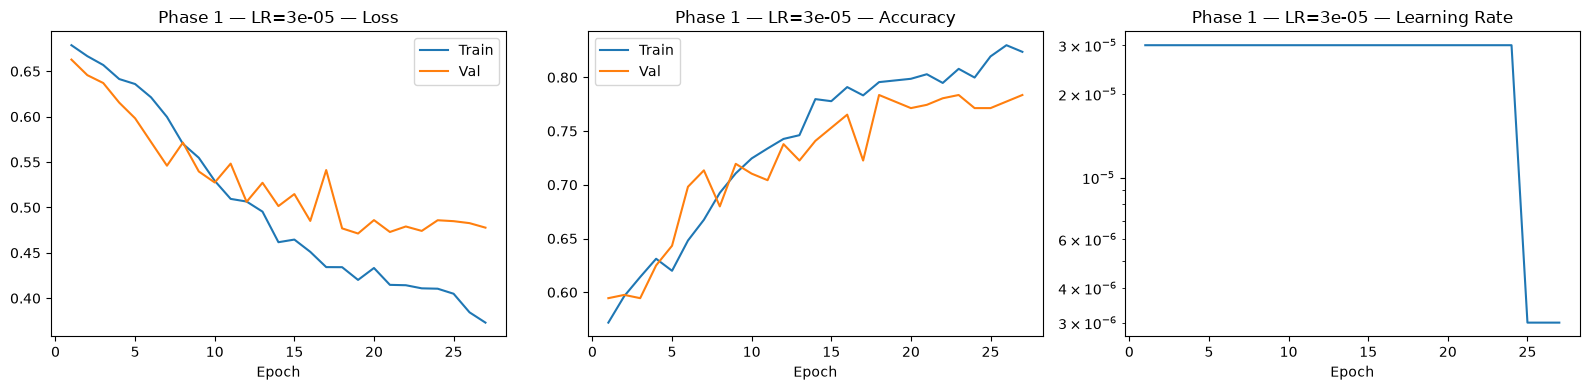


Experiment: phase1_lr_1e-04
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


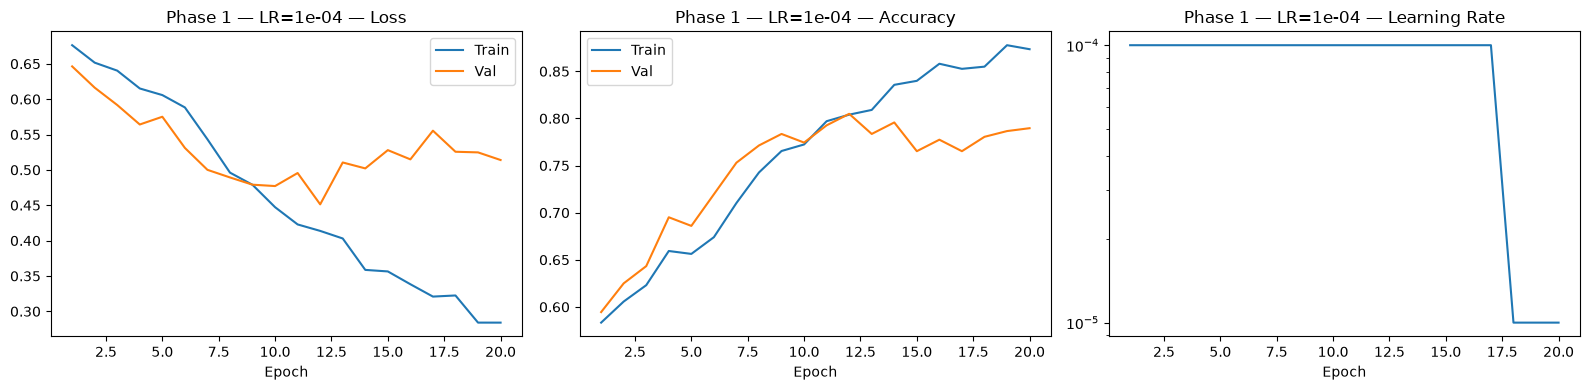


Experiment: phase1_lr_3e-04
head_lr=0.0003 backbone_lr=2.9999999999999997e-05 weight_decay=0.0001 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6851 acc 0.5683 | val_loss 0.6372 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6505 acc 0.6231 | val_loss 0.6275 acc 0.6067


  [warmup] epoch  3 | train_loss 0.6301 acc 0.6339 | val_loss 0.5763 acc 0.6799


  [warmup] epoch  4 | train_loss 0.6058 acc 0.6759 | val_loss 0.5579 acc 0.7012


...

  epoch 11 | train_loss 0.3761 acc 0.8299 | val_loss 0.5131 acc 0.7835 | lr(head) 3.00e-04


  epoch 12 | train_loss 0.3606 acc 0.8418 | val_loss 0.5200 acc 0.7500 | lr(head) 3.00e-04


  epoch 13 | train_loss 0.3243 acc 0.8603 | val_loss 0.5843 acc 0.7470 | lr(head) 3.00e-05


  epoch 14 | train_loss 0.2911 acc 0.8727 | val_loss 0.5523 acc 0.7744 | lr(head) 3.00e-05


  epoch 15 | train_loss 0.2640 acc 0.8985 | val_loss 0.5749 acc 0.7652 | lr(head) 3.00e-05
  Early stopping at epoch 15.


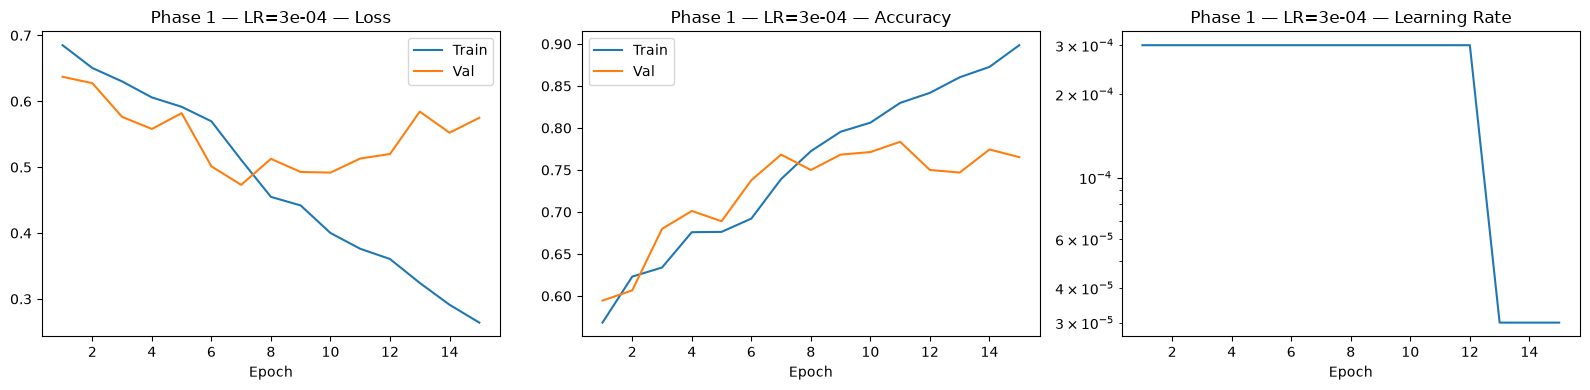


Experiment: phase1_lr_1e-03
head_lr=0.001 backbone_lr=0.0001 weight_decay=0.0001 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.7110 acc 0.5652 | val_loss 0.6526 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6662 acc 0.5883 | val_loss 0.6287 acc 0.5945


  [warmup] epoch  3 | train_loss 0.6333 acc 0.6292 | val_loss 0.5591 acc 0.6951


  [warmup] epoch  4 | train_loss 0.6273 acc 0.6447 | val_loss 0.5852 acc 0.6768


...

  epoch 18 | train_loss 0.3319 acc 0.8592 | val_loss 0.7010 acc 0.7287 | lr(head) 1.00e-03


  epoch 19 | train_loss 0.3098 acc 0.8615 | val_loss 0.6419 acc 0.7134 | lr(head) 1.00e-03


  epoch 20 | train_loss 0.3084 acc 0.8746 | val_loss 0.6028 acc 0.7317 | lr(head) 1.00e-04


  epoch 21 | train_loss 0.2201 acc 0.9090 | val_loss 0.6311 acc 0.7378 | lr(head) 1.00e-04


  epoch 22 | train_loss 0.2062 acc 0.9159 | val_loss 0.7061 acc 0.7348 | lr(head) 1.00e-04
  Early stopping at epoch 22.


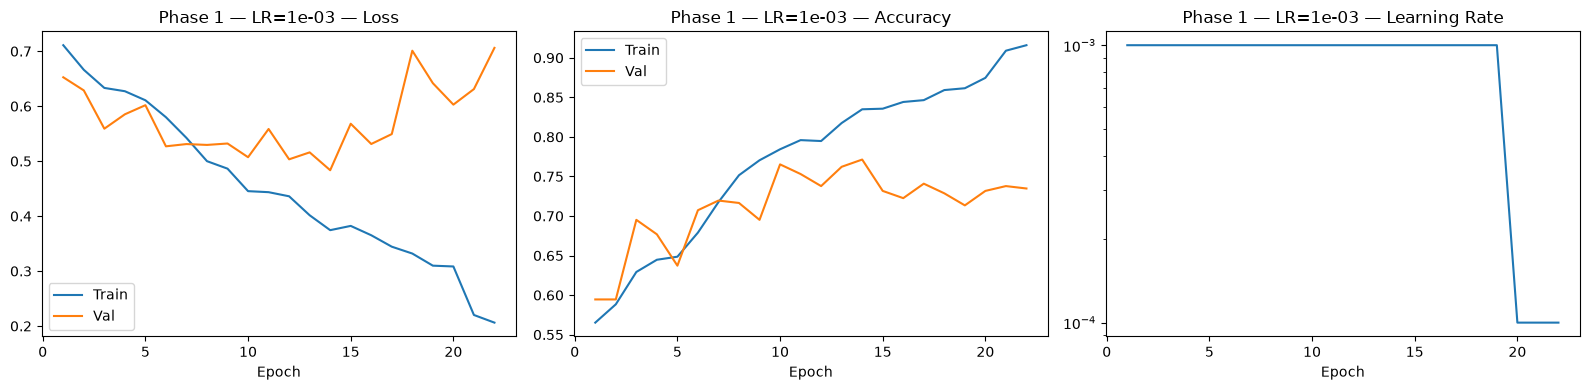

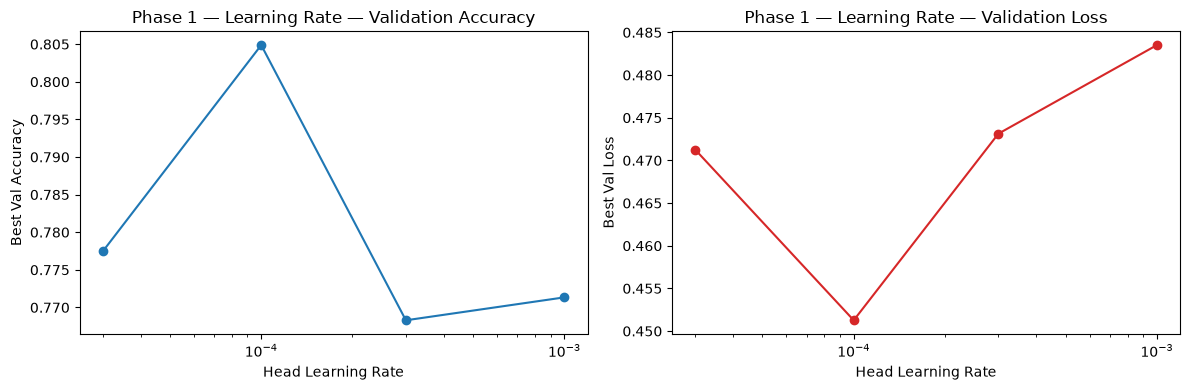

Winner: head_lr=1e-04, backbone_lr=1e-05 (val_acc=0.8049, val_loss=0.4513)
  removed non-winning checkpoint: checkpoints\phase1_lr_3e-05.pth
  removed non-winning checkpoint: checkpoints\phase1_lr_3e-04.pth
  removed non-winning checkpoint: checkpoints\phase1_lr_1e-03.pth


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path
0,phase1_lr_3e-05,0.00003,0.000003,0.0001,plateau,adamw,CrossEntropyLoss,19,27,0.471264,0.777439,1369.5,checkpoints\phase1_lr_3e-05.pth
1,phase1_lr_1e-04,0.00010,0.000010,0.0001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1051.8,checkpoints\phase1_lr_1e-04.pth
2,phase1_lr_3e-04,0.00030,0.000030,0.0001,plateau,adamw,CrossEntropyLoss,7,15,0.473131,0.768293,699.3,checkpoints\phase1_lr_3e-04.pth
3,phase1_lr_1e-03,0.00100,0.000100,0.0001,plateau,adamw,CrossEntropyLoss,14,22,0.483514,0.771341,1143.4,checkpoints\phase1_lr_1e-03.pth


In [11]:
LR_GRID = [3e-5, 1e-4, 3e-4, 1e-3]

phase1_results = []
phase1_histories = {}
for head_lr in LR_GRID:
    backbone_lr = head_lr / 10
    name = f"phase1_lr_{head_lr:.0e}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=head_lr, backbone_lr=backbone_lr,
        weight_decay=BASELINE["weight_decay"], scheduler_name=BASELINE["scheduler"],
        train_loader=train_loader, val_loader=val_loader,
        loss_fn=build_loss(BASELINE["loss"]), optimizer_name=BASELINE["optimizer"],
    )
    phase1_histories[name] = hist
    phase1_results.append(row)
    plot_curves(hist, f"Phase 1 — LR={head_lr:.0e}")

phase1_df = pd.DataFrame(phase1_results)
plot_phase_comparison(phase1_df, "head_lr", "Head Learning Rate", "Phase 1 — Learning Rate", log_x=True)

best_lr_row = select_best_variant(phase1_df)
BEST_HEAD_LR = best_lr_row["head_lr"]
BEST_BACKBONE_LR = best_lr_row["backbone_lr"]
print(f"Winner: head_lr={BEST_HEAD_LR:.0e}, backbone_lr={BEST_BACKBONE_LR:.0e} "
      f"(val_acc={best_lr_row['best_val_accuracy']:.4f}, val_loss={best_lr_row['best_val_loss']:.4f})")

keep_only_best_checkpoint(phase1_results, best_lr_row["experiment"])
all_phase_results.append(best_lr_row.to_dict())
phase1_df


## Phase 2 — Weight Decay Optimization

Best LR from Phase 1 is frozen. Only weight decay is varied.


Experiment: phase2_wd_1e-05
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


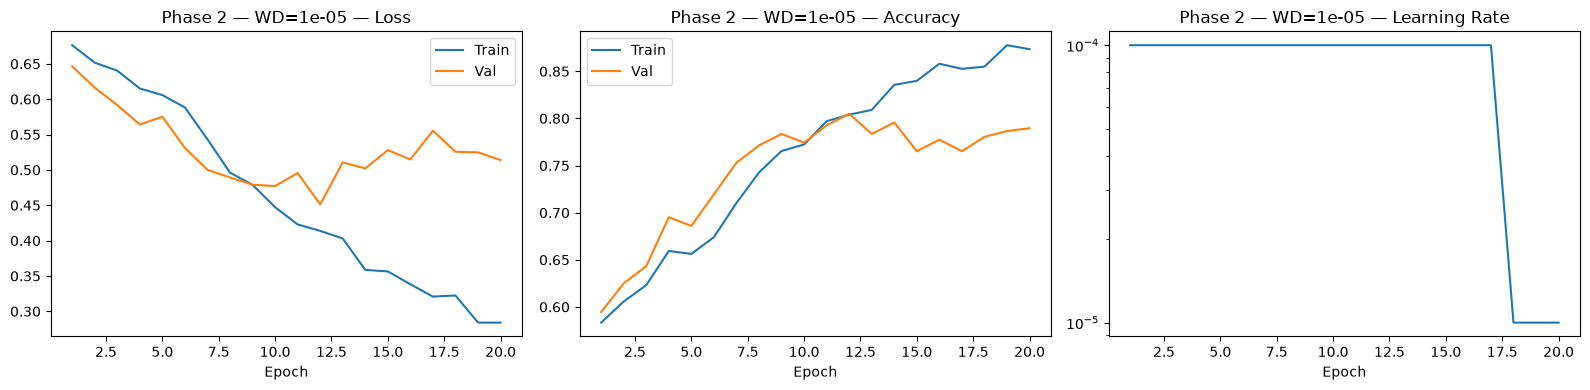


Experiment: phase2_wd_1e-04
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


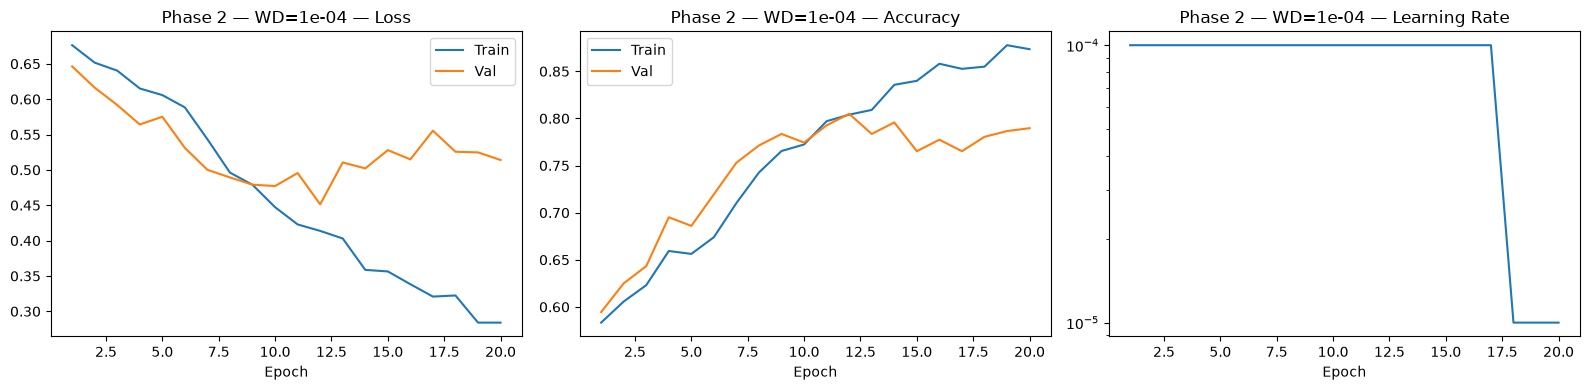


Experiment: phase2_wd_1e-03
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.001 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6769 acc 0.5795 | val_loss 0.6468 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6561 acc 0.5995 | val_loss 0.6175 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6432 acc 0.6181 | val_loss 0.5878 acc 0.6555


  [warmup] epoch  4 | train_loss 0.6149 acc 0.6667 | val_loss 0.5655 acc 0.7012


...

  epoch 16 | train_loss 0.3457 acc 0.8538 | val_loss 0.5299 acc 0.7744 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3227 acc 0.8592 | val_loss 0.5776 acc 0.7500 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3194 acc 0.8565 | val_loss 0.5458 acc 0.7652 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2867 acc 0.8738 | val_loss 0.5397 acc 0.7713 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2869 acc 0.8758 | val_loss 0.5367 acc 0.7744 | lr(head) 1.00e-05
  Early stopping at epoch 20.


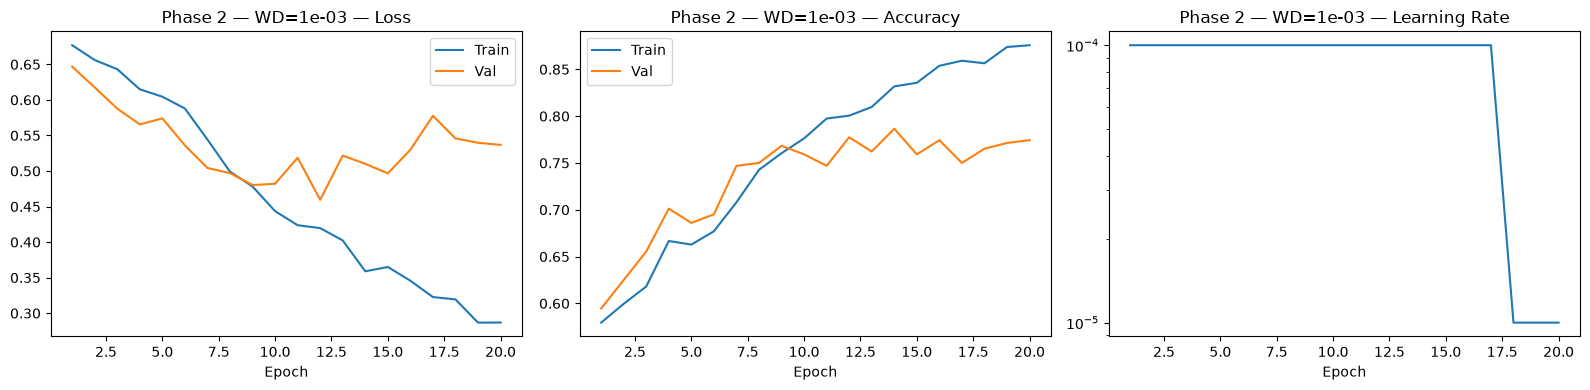


Experiment: phase2_wd_1e-02
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.01 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6760 acc 0.5845 | val_loss 0.6436 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6524 acc 0.6088 | val_loss 0.6222 acc 0.6067


  [warmup] epoch  3 | train_loss 0.6442 acc 0.6227 | val_loss 0.5906 acc 0.6372


  [warmup] epoch  4 | train_loss 0.6192 acc 0.6601 | val_loss 0.5681 acc 0.7073


...

  epoch 16 | train_loss 0.3330 acc 0.8576 | val_loss 0.5029 acc 0.8018 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3191 acc 0.8596 | val_loss 0.5453 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3187 acc 0.8611 | val_loss 0.5146 acc 0.7896 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2776 acc 0.8789 | val_loss 0.5214 acc 0.7774 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2745 acc 0.8850 | val_loss 0.5269 acc 0.7866 | lr(head) 1.00e-05
  Early stopping at epoch 20.


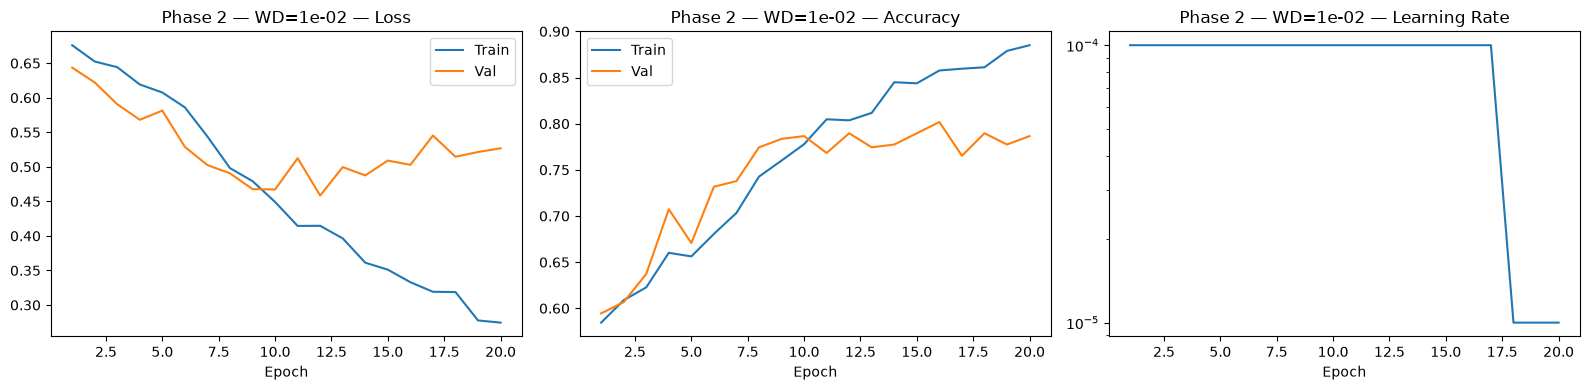

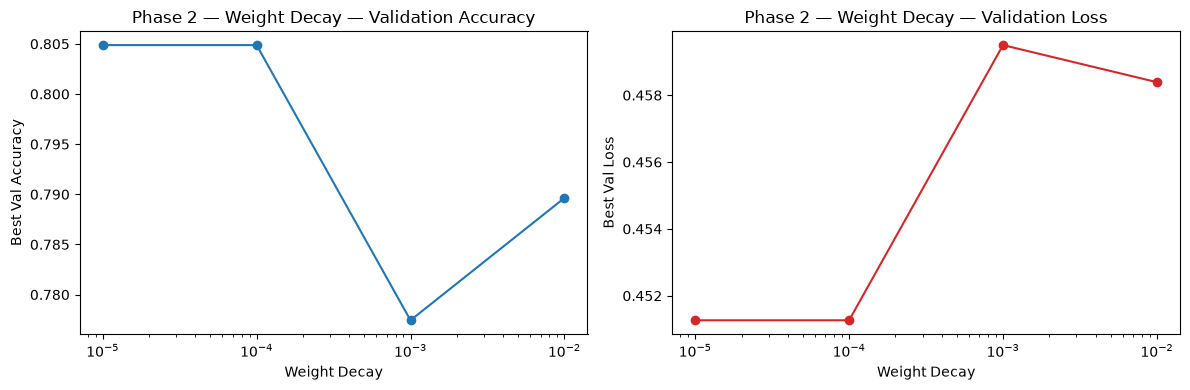

Winner: weight_decay=1e-05 (val_acc=0.8049, val_loss=0.4513)
  removed non-winning checkpoint: checkpoints\phase2_wd_1e-04.pth
  removed non-winning checkpoint: checkpoints\phase2_wd_1e-03.pth
  removed non-winning checkpoint: checkpoints\phase2_wd_1e-02.pth


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path
0,phase2_wd_1e-05,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1453.9,checkpoints\phase2_wd_1e-05.pth
1,phase2_wd_1e-04,0.0001,0.00001,0.00010,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1472.2,checkpoints\phase2_wd_1e-04.pth
2,phase2_wd_1e-03,0.0001,0.00001,0.00100,plateau,adamw,CrossEntropyLoss,12,20,0.459500,0.777439,1595.3,checkpoints\phase2_wd_1e-03.pth
3,phase2_wd_1e-02,0.0001,0.00001,0.01000,plateau,adamw,CrossEntropyLoss,12,20,0.458390,0.789634,1362.8,checkpoints\phase2_wd_1e-02.pth


In [21]:
WD_GRID = [1e-5, 1e-4, 1e-3, 1e-2]

phase2_results = []
phase2_histories = {}
for wd in WD_GRID:
    name = f"phase2_wd_{wd:.0e}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=wd, scheduler_name=BASELINE["scheduler"],
        train_loader=train_loader, val_loader=val_loader,
        loss_fn=build_loss(BASELINE["loss"]), optimizer_name=BASELINE["optimizer"],
    )
    phase2_histories[name] = hist
    phase2_results.append(row)
    plot_curves(hist, f"Phase 2 — WD={wd:.0e}")

phase2_df = pd.DataFrame(phase2_results)
plot_phase_comparison(phase2_df, "weight_decay", "Weight Decay", "Phase 2 — Weight Decay", log_x=True)

best_wd_row = select_best_variant(phase2_df)
BEST_WEIGHT_DECAY = best_wd_row["weight_decay"]
print(f"Winner: weight_decay={BEST_WEIGHT_DECAY:.0e} "
      f"(val_acc={best_wd_row['best_val_accuracy']:.4f}, val_loss={best_wd_row['best_val_loss']:.4f})")

keep_only_best_checkpoint(phase2_results, best_wd_row["experiment"])
all_phase_results.append(best_wd_row.to_dict())
phase2_df


## Phase 3 — Scheduler Optimization

Best LR and weight decay are frozen. Compares `ReduceLROnPlateau`, `CosineAnnealingLR`, and
`OneCycleLR`.


Experiment: phase3_sched_plateau
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


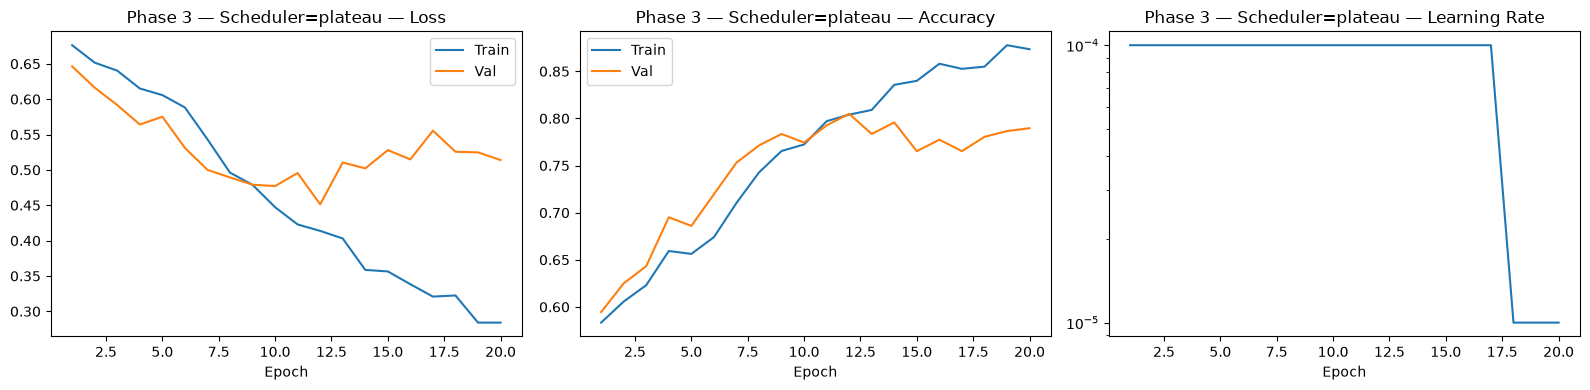


Experiment: phase3_sched_cosine
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=cosine optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3391 acc 0.8515 | val_loss 0.5148 acc 0.7774 | lr(head) 7.75e-05


  epoch 17 | train_loss 0.3282 acc 0.8480 | val_loss 0.5336 acc 0.7805 | lr(head) 7.37e-05


  epoch 18 | train_loss 0.3270 acc 0.8530 | val_loss 0.5095 acc 0.7835 | lr(head) 6.97e-05


  epoch 19 | train_loss 0.3030 acc 0.8681 | val_loss 0.5077 acc 0.7713 | lr(head) 6.55e-05


  epoch 20 | train_loss 0.3018 acc 0.8611 | val_loss 0.5510 acc 0.7683 | lr(head) 6.11e-05
  Early stopping at epoch 20.


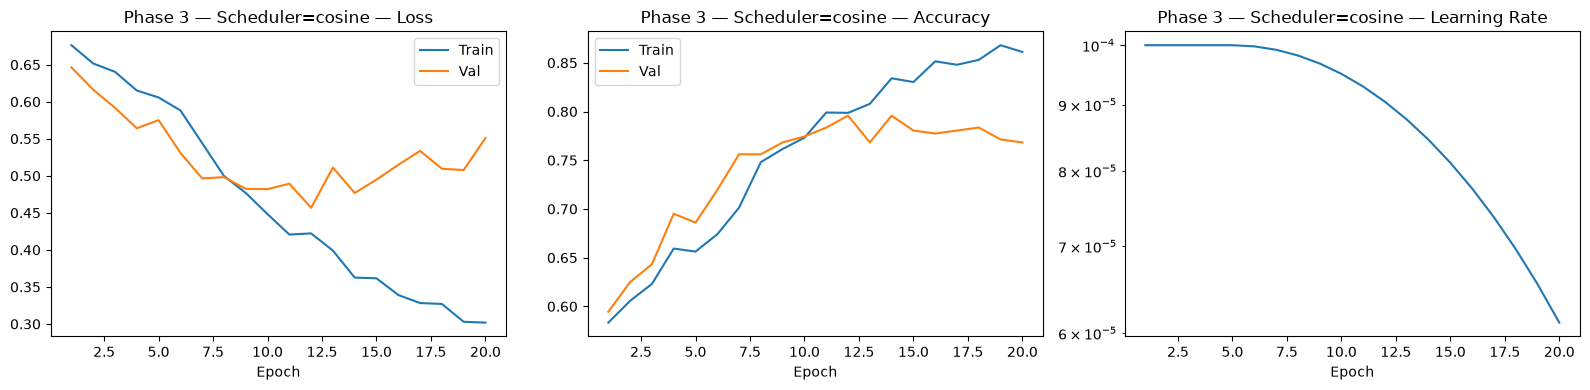


Experiment: phase3_sched_onecycle
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=onecycle optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 23 | train_loss 0.3191 acc 0.8588 | val_loss 0.5093 acc 0.7713 | lr(head) 7.86e-05


  epoch 24 | train_loss 0.3045 acc 0.8603 | val_loss 0.4996 acc 0.7622 | lr(head) 7.31e-05


  epoch 25 | train_loss 0.2972 acc 0.8700 | val_loss 0.5570 acc 0.7530 | lr(head) 6.72e-05


  epoch 26 | train_loss 0.2738 acc 0.8777 | val_loss 0.6394 acc 0.7348 | lr(head) 6.11e-05


  epoch 27 | train_loss 0.2447 acc 0.8970 | val_loss 0.5752 acc 0.7591 | lr(head) 5.48e-05
  Early stopping at epoch 27.


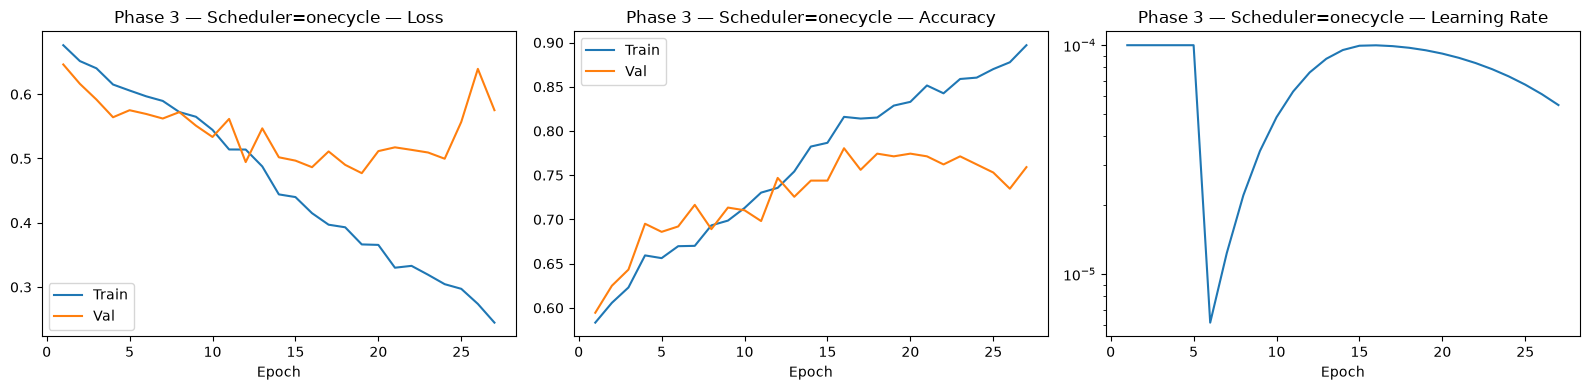

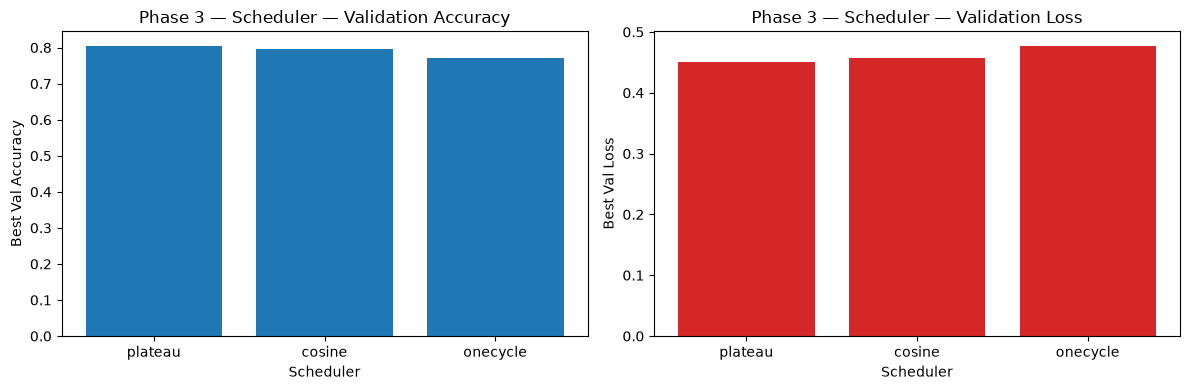

Winner: scheduler=plateau (val_acc=0.8049, val_loss=0.4513)
  removed non-winning checkpoint: checkpoints\phase3_sched_cosine.pth
  removed non-winning checkpoint: checkpoints\phase3_sched_onecycle.pth


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path
0,phase3_sched_plateau,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1171.6,checkpoints\phase3_sched_plateau.pth
1,phase3_sched_cosine,0.0001,0.00001,0.00001,cosine,adamw,CrossEntropyLoss,12,20,0.456768,0.795732,1082.9,checkpoints\phase3_sched_cosine.pth
2,phase3_sched_onecycle,0.0001,0.00001,0.00001,onecycle,adamw,CrossEntropyLoss,19,27,0.477171,0.771341,1838.5,checkpoints\phase3_sched_onecycle.pth


In [22]:
SCHEDULERS = ["plateau", "cosine", "onecycle"]

phase3_results = []
phase3_histories = {}
for sched_name in SCHEDULERS:
    name = f"phase3_sched_{sched_name}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=BEST_WEIGHT_DECAY, scheduler_name=sched_name,
        train_loader=train_loader, val_loader=val_loader,
        loss_fn=build_loss(BASELINE["loss"]), optimizer_name=BASELINE["optimizer"],
    )
    phase3_histories[name] = hist
    phase3_results.append(row)
    plot_curves(hist, f"Phase 3 — Scheduler={sched_name}")

phase3_df = pd.DataFrame(phase3_results)
plot_phase_comparison(phase3_df, "scheduler", "Scheduler", "Phase 3 — Scheduler", categorical=True)

best_sched_row = select_best_variant(phase3_df)
BEST_SCHEDULER = best_sched_row["scheduler"]
print(f"Winner: scheduler={BEST_SCHEDULER} "
      f"(val_acc={best_sched_row['best_val_accuracy']:.4f}, val_loss={best_sched_row['best_val_loss']:.4f})")

keep_only_best_checkpoint(phase3_results, best_sched_row["experiment"])
all_phase_results.append(best_sched_row.to_dict())
phase3_df


## Phase 4 — Augmentation

Best LR, weight decay, and scheduler are frozen. Only the training-set transform strength varies
(`none` / `light` / `baseline` / `heavy`, defined earlier). The validation/test transform never
changes, so this isolates the effect of augmentation on generalization.


Experiment: phase4_aug_none
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6736 acc 0.5853 | val_loss 0.6374 acc 0.6037


  [warmup] epoch  2 | train_loss 0.6457 acc 0.6316 | val_loss 0.6044 acc 0.6646


  [warmup] epoch  3 | train_loss 0.6148 acc 0.6582 | val_loss 0.5722 acc 0.6890


  [warmup] epoch  4 | train_loss 0.5919 acc 0.6806 | val_loss 0.5793 acc 0.6768


...

  epoch 11 | train_loss 0.1129 acc 0.9606 | val_loss 0.7969 acc 0.7530 | lr(head) 1.00e-04


  epoch 12 | train_loss 0.0792 acc 0.9734 | val_loss 0.8488 acc 0.7530 | lr(head) 1.00e-04


  epoch 13 | train_loss 0.0645 acc 0.9776 | val_loss 0.9271 acc 0.7561 | lr(head) 1.00e-05


  epoch 14 | train_loss 0.0381 acc 0.9888 | val_loss 0.8910 acc 0.7470 | lr(head) 1.00e-05


  epoch 15 | train_loss 0.0355 acc 0.9884 | val_loss 0.9205 acc 0.7317 | lr(head) 1.00e-05
  Early stopping at epoch 15.


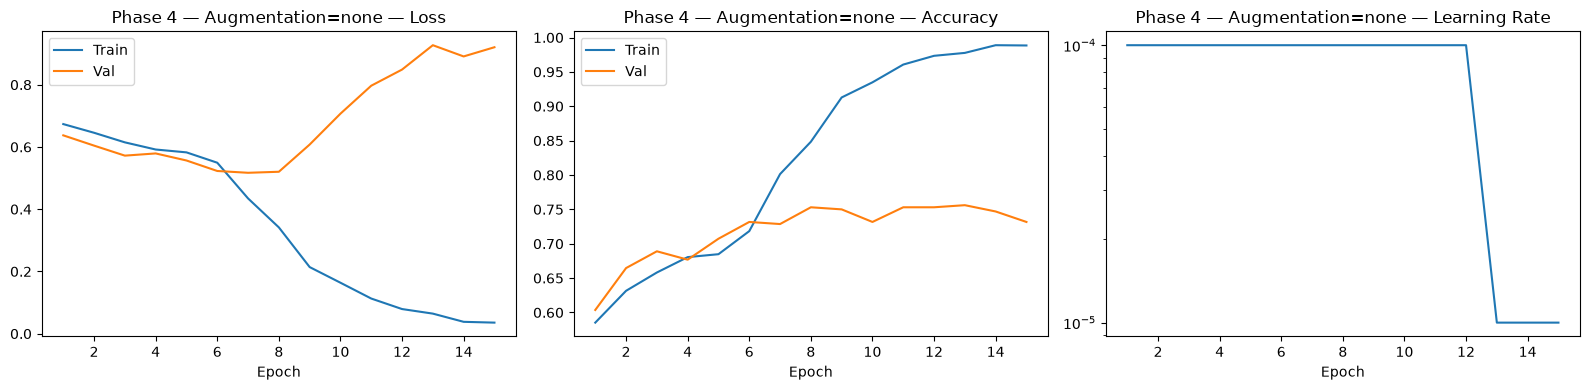


Experiment: phase4_aug_light
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6714 acc 0.5864 | val_loss 0.6304 acc 0.6067


  [warmup] epoch  2 | train_loss 0.6471 acc 0.6227 | val_loss 0.6007 acc 0.6707


  [warmup] epoch  3 | train_loss 0.6247 acc 0.6447 | val_loss 0.5834 acc 0.6951


  [warmup] epoch  4 | train_loss 0.5990 acc 0.6752 | val_loss 0.5884 acc 0.6738


...

  epoch 11 | train_loss 0.2325 acc 0.9078 | val_loss 0.6141 acc 0.7530 | lr(head) 1.00e-04


  epoch 12 | train_loss 0.1930 acc 0.9271 | val_loss 0.7793 acc 0.7256 | lr(head) 1.00e-04


  epoch 13 | train_loss 0.1574 acc 0.9410 | val_loss 0.7111 acc 0.7409 | lr(head) 1.00e-05


  epoch 14 | train_loss 0.1144 acc 0.9579 | val_loss 0.6954 acc 0.7500 | lr(head) 1.00e-05


  epoch 15 | train_loss 0.0997 acc 0.9672 | val_loss 0.7108 acc 0.7530 | lr(head) 1.00e-05
  Early stopping at epoch 15.


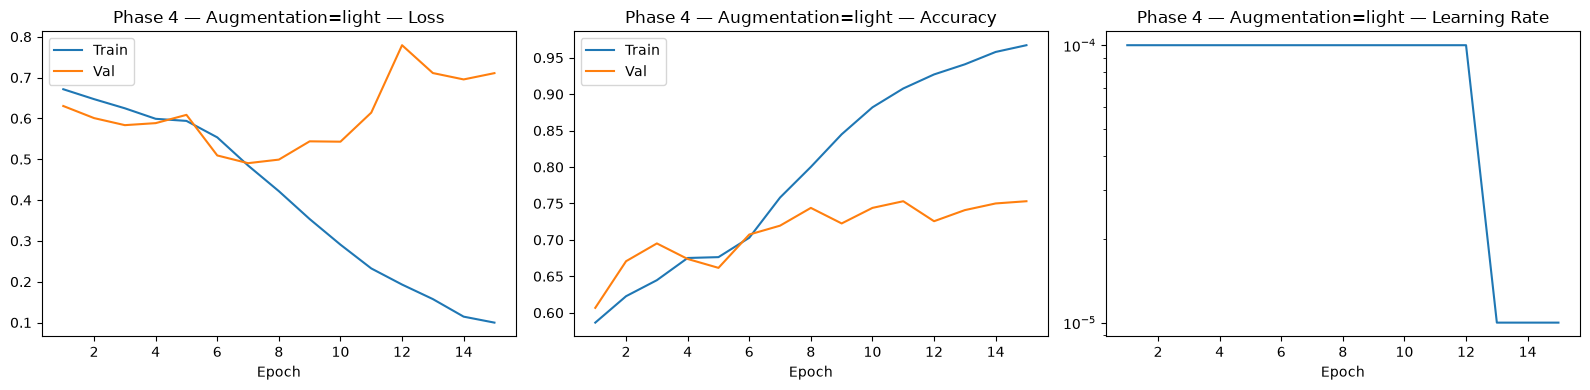


Experiment: phase4_aug_baseline
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


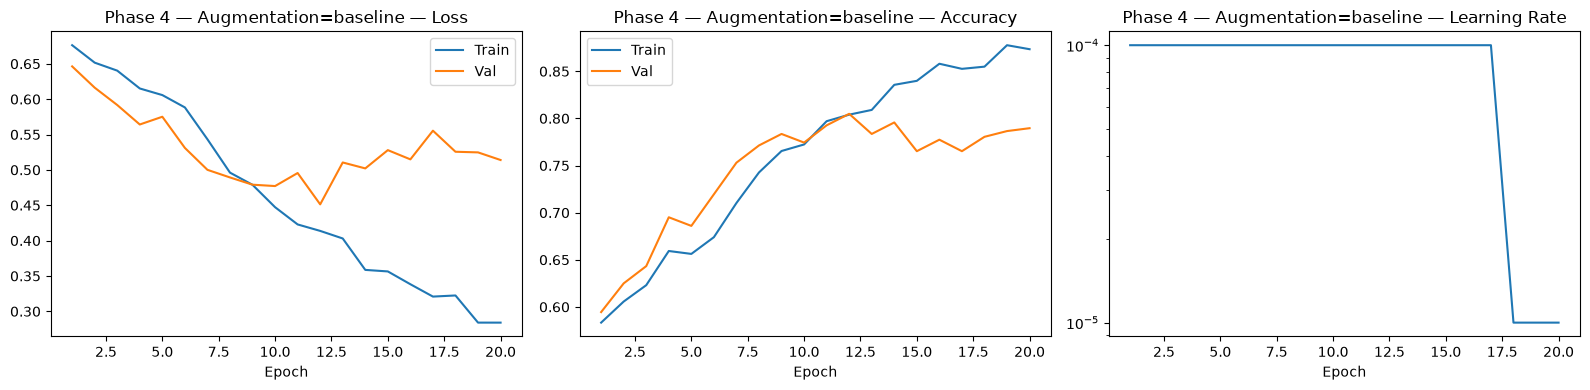


Experiment: phase4_aug_heavy
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6763 acc 0.5826 | val_loss 0.6525 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6574 acc 0.6057 | val_loss 0.6218 acc 0.6006


  [warmup] epoch  3 | train_loss 0.6498 acc 0.6069 | val_loss 0.5920 acc 0.6677


  [warmup] epoch  4 | train_loss 0.6255 acc 0.6381 | val_loss 0.6177 acc 0.6128


...

  epoch 14 | train_loss 0.4247 acc 0.7948 | val_loss 0.5224 acc 0.7591 | lr(head) 1.00e-04


  epoch 15 | train_loss 0.4411 acc 0.7982 | val_loss 0.5210 acc 0.7500 | lr(head) 1.00e-04


  epoch 16 | train_loss 0.4103 acc 0.8067 | val_loss 0.5189 acc 0.7652 | lr(head) 1.00e-05


  epoch 17 | train_loss 0.3903 acc 0.8202 | val_loss 0.5162 acc 0.7591 | lr(head) 1.00e-05


  epoch 18 | train_loss 0.3920 acc 0.8075 | val_loss 0.5385 acc 0.7470 | lr(head) 1.00e-05
  Early stopping at epoch 18.


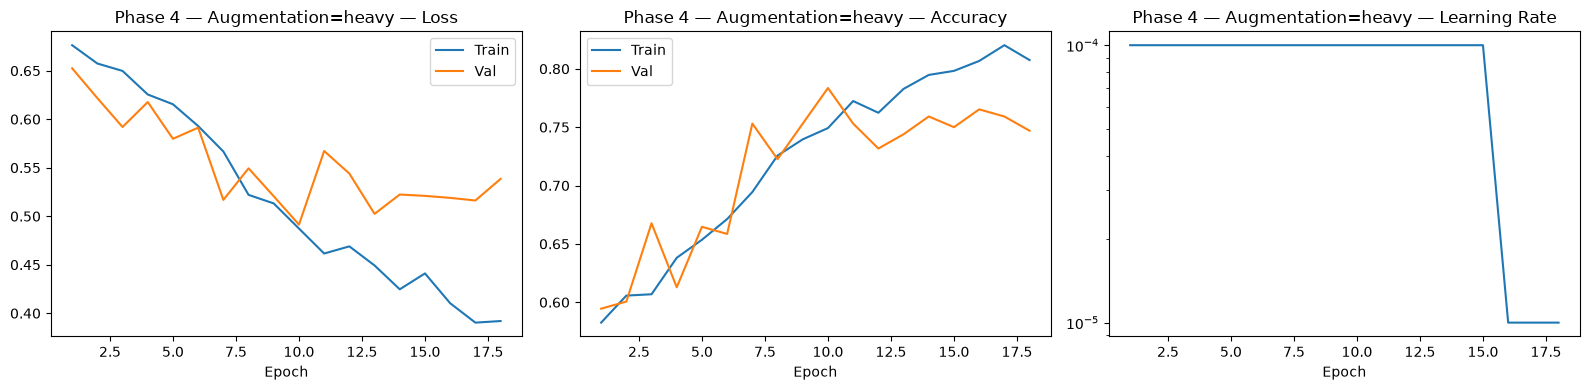

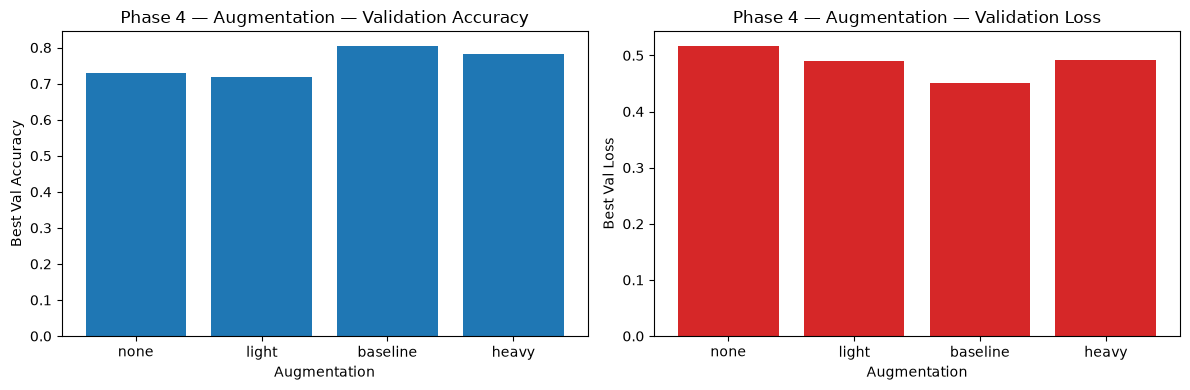

Winner: augmentation=baseline (val_acc=0.8049, val_loss=0.4513)
  removed non-winning checkpoint: checkpoints\phase4_aug_none.pth
  removed non-winning checkpoint: checkpoints\phase4_aug_light.pth
  removed non-winning checkpoint: checkpoints\phase4_aug_heavy.pth


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path,augmentation
0,phase4_aug_none,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,7,15,0.517054,0.728659,811.1,checkpoints\phase4_aug_none.pth,none
1,phase4_aug_light,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,7,15,0.490327,0.719512,839.5,checkpoints\phase4_aug_light.pth,light
2,phase4_aug_baseline,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1405.6,checkpoints\phase4_aug_baseline.pth,baseline
3,phase4_aug_heavy,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,10,18,0.491377,0.783537,850.3,checkpoints\phase4_aug_heavy.pth,heavy


In [23]:
AUGMENTATION_VARIANTS = ["none", "light", "baseline", "heavy"]

phase4_results = []
phase4_histories = {}
for aug_name in AUGMENTATION_VARIANTS:
    aug_train_loader, _, _ = make_loaders(TRANSFORM_VARIANTS[aug_name])
    name = f"phase4_aug_{aug_name}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=BEST_WEIGHT_DECAY, scheduler_name=BEST_SCHEDULER,
        train_loader=aug_train_loader, val_loader=val_loader,
        loss_fn=build_loss(BASELINE["loss"]), optimizer_name=BASELINE["optimizer"],
    )
    row["augmentation"] = aug_name
    phase4_histories[name] = hist
    phase4_results.append(row)
    plot_curves(hist, f"Phase 4 — Augmentation={aug_name}")

phase4_df = pd.DataFrame(phase4_results)
plot_phase_comparison(phase4_df, "augmentation", "Augmentation", "Phase 4 — Augmentation", categorical=True)

best_aug_row = select_best_variant(phase4_df)
BEST_AUGMENTATION = best_aug_row["augmentation"]
print(f"Winner: augmentation={BEST_AUGMENTATION} "
      f"(val_acc={best_aug_row['best_val_accuracy']:.4f}, val_loss={best_aug_row['best_val_loss']:.4f})")

keep_only_best_checkpoint(phase4_results, best_aug_row["experiment"])
all_phase_results.append(best_aug_row.to_dict())

# Rebuild the shared train_loader with the winning augmentation so later phases use it
train_loader, val_loader, test_loader = make_loaders(TRANSFORM_VARIANTS[BEST_AUGMENTATION])
phase4_df


## Phase 5 — Class Imbalance / Loss Function

Best LR, weight decay, scheduler, and augmentation are frozen. Compares plain cross-entropy,
class-weighted cross-entropy (weights computed from the train split's class frequencies), and
focal loss (`gamma=2`).


Experiment: phase5_loss_ce_unweighted
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


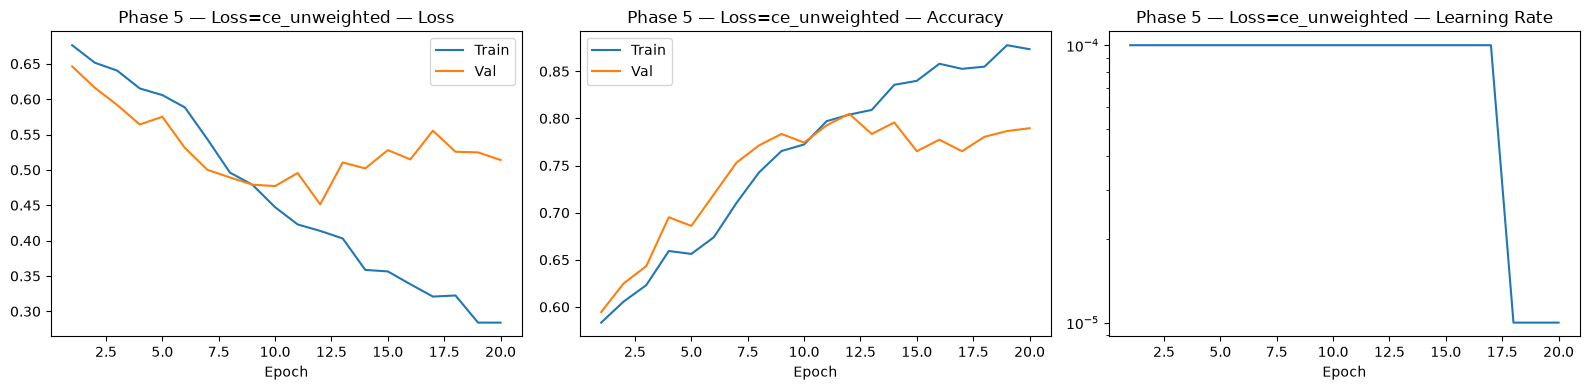


Experiment: phase5_loss_ce_class_weighted
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6914 acc 0.5216 | val_loss 0.6544 acc 0.7012


  [warmup] epoch  2 | train_loss 0.6696 acc 0.5868 | val_loss 0.6299 acc 0.7073


  [warmup] epoch  3 | train_loss 0.6594 acc 0.6046 | val_loss 0.5981 acc 0.7012


  [warmup] epoch  4 | train_loss 0.6299 acc 0.6447 | val_loss 0.5730 acc 0.6738


...

  epoch 16 | train_loss 0.3491 acc 0.8461 | val_loss 0.5112 acc 0.7591 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3250 acc 0.8495 | val_loss 0.5444 acc 0.7713 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3259 acc 0.8530 | val_loss 0.5286 acc 0.7744 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2937 acc 0.8638 | val_loss 0.5323 acc 0.7652 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2868 acc 0.8704 | val_loss 0.5361 acc 0.7774 | lr(head) 1.00e-05
  Early stopping at epoch 20.


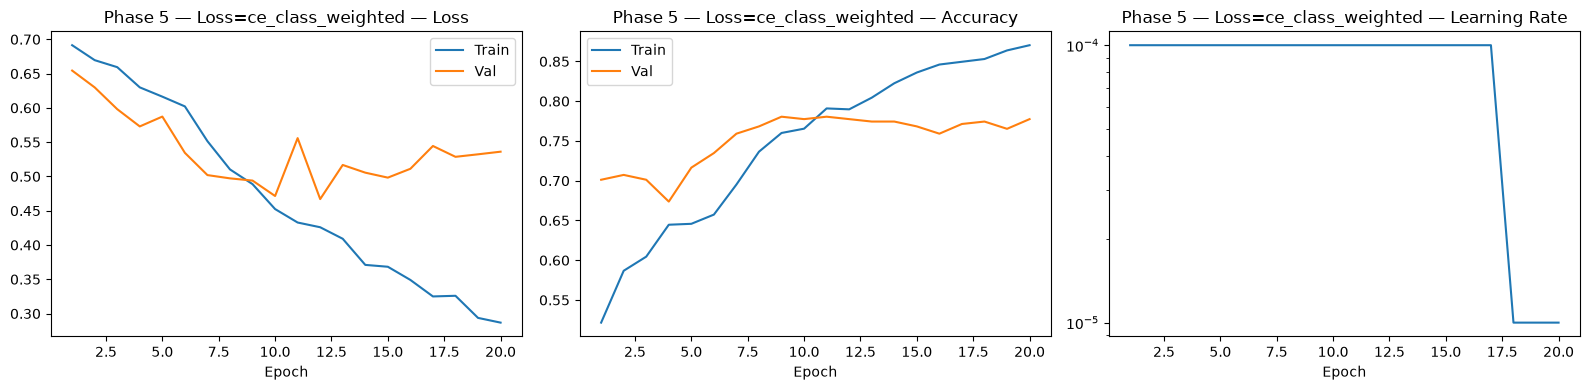


Experiment: phase5_loss_focal_loss
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=FocalLoss


  [warmup] epoch  1 | train_loss 0.1729 acc 0.5648 | val_loss 0.1626 acc 0.5945


  [warmup] epoch  2 | train_loss 0.1659 acc 0.6026 | val_loss 0.1544 acc 0.6341


  [warmup] epoch  3 | train_loss 0.1631 acc 0.6223 | val_loss 0.1487 acc 0.6829


  [warmup] epoch  4 | train_loss 0.1578 acc 0.6478 | val_loss 0.1451 acc 0.7043


...

  epoch 16 | train_loss 0.0941 acc 0.8426 | val_loss 0.1266 acc 0.7835 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.0876 acc 0.8438 | val_loss 0.1372 acc 0.7622 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.0879 acc 0.8476 | val_loss 0.1380 acc 0.7774 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.0789 acc 0.8642 | val_loss 0.1417 acc 0.7744 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.0790 acc 0.8696 | val_loss 0.1392 acc 0.7805 | lr(head) 1.00e-05
  Early stopping at epoch 20.


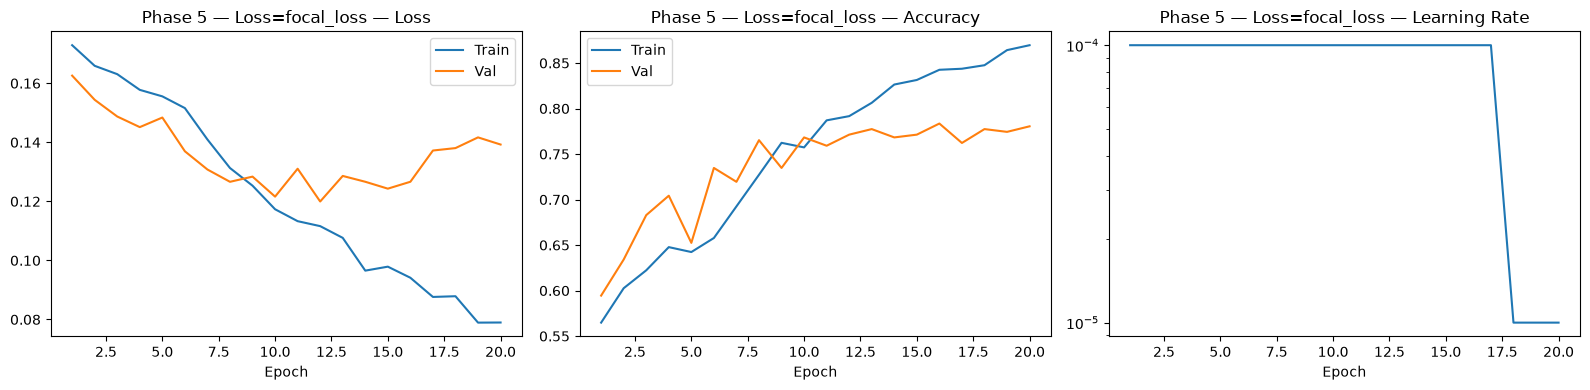

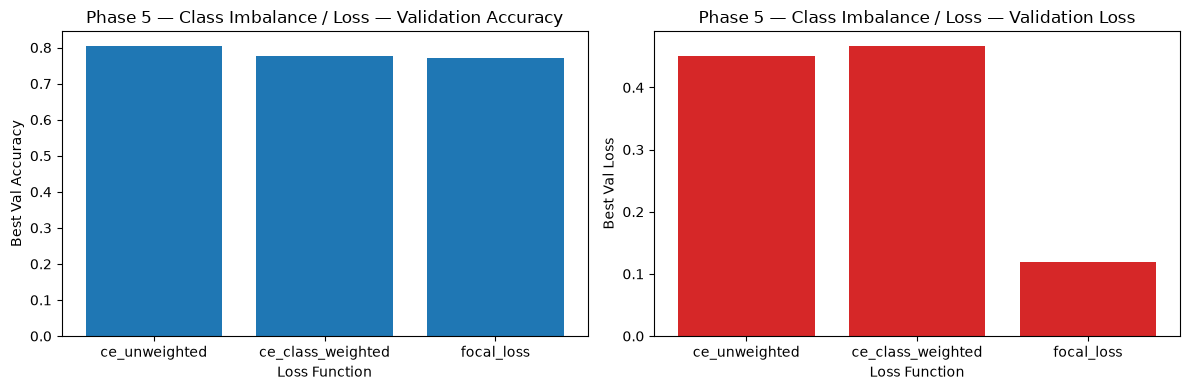

Winner: loss=ce_unweighted (val_acc=0.8049, val_loss=0.4513)
  removed non-winning checkpoint: checkpoints\phase5_loss_ce_class_weighted.pth
  removed non-winning checkpoint: checkpoints\phase5_loss_focal_loss.pth


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path,loss_variant
0,phase5_loss_ce_unweighted,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,925.4,checkpoints\phase5_loss_ce_unweighted.pth,ce_unweighted
1,phase5_loss_ce_class_weighted,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.466986,0.777439,1041.9,checkpoints\phase5_loss_ce_class_weighted.pth,ce_class_weighted
2,phase5_loss_focal_loss,0.0001,0.00001,0.00001,plateau,adamw,FocalLoss,12,20,0.119950,0.771341,1225.7,checkpoints\phase5_loss_focal_loss.pth,focal_loss


In [24]:
LOSS_VARIANTS = ["ce_unweighted", "ce_class_weighted", "focal_loss"]

phase5_results = []
phase5_histories = {}
for loss_name in LOSS_VARIANTS:
    name = f"phase5_loss_{loss_name}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=BEST_WEIGHT_DECAY, scheduler_name=BEST_SCHEDULER,
        train_loader=train_loader, val_loader=val_loader,
        loss_fn=build_loss(loss_name), optimizer_name=BASELINE["optimizer"],
    )
    row["loss_variant"] = loss_name
    phase5_histories[name] = hist
    phase5_results.append(row)
    plot_curves(hist, f"Phase 5 — Loss={loss_name}")

phase5_df = pd.DataFrame(phase5_results)
plot_phase_comparison(phase5_df, "loss_variant", "Loss Function", "Phase 5 — Class Imbalance / Loss", categorical=True)

best_loss_row = select_best_variant(phase5_df)
BEST_LOSS = best_loss_row["loss_variant"]
print(f"Winner: loss={BEST_LOSS} "
      f"(val_acc={best_loss_row['best_val_accuracy']:.4f}, val_loss={best_loss_row['best_val_loss']:.4f})")

keep_only_best_checkpoint(phase5_results, best_loss_row["experiment"])
all_phase_results.append(best_loss_row.to_dict())
phase5_df


## Phase 6 — Optimizer

Best LR, weight decay, scheduler, augmentation, and loss are frozen. Compares `AdamW`, `Adam`, and
`SGD` (momentum=0.9).


Experiment: phase6_opt_adamw
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


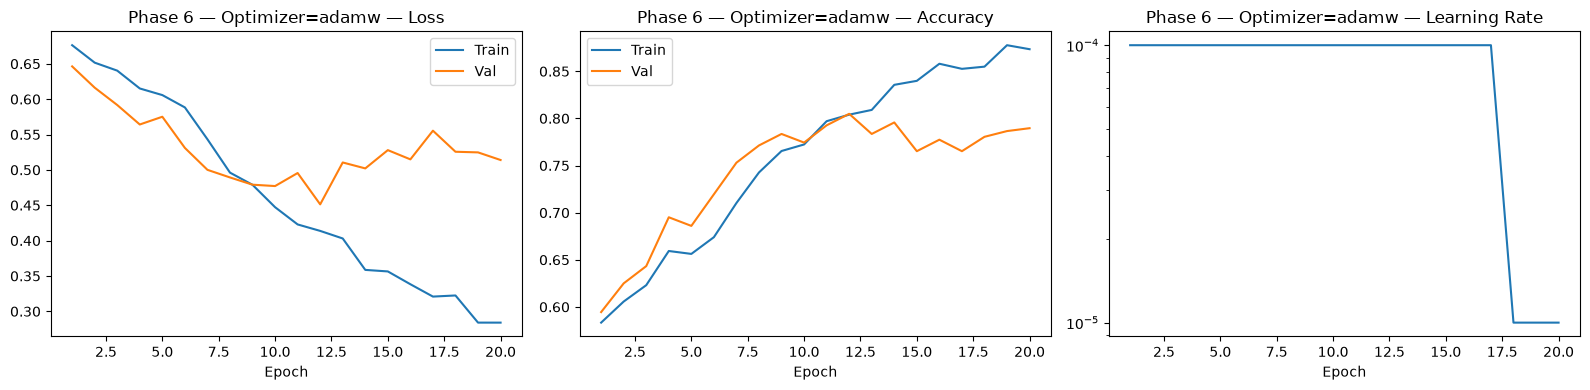


Experiment: phase6_opt_adam
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adam loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6770 acc 0.5802 | val_loss 0.6453 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6544 acc 0.6034 | val_loss 0.6159 acc 0.6280


  [warmup] epoch  3 | train_loss 0.6423 acc 0.6289 | val_loss 0.5840 acc 0.6799


  [warmup] epoch  4 | train_loss 0.6178 acc 0.6551 | val_loss 0.5649 acc 0.7073


...

  epoch 16 | train_loss 0.3357 acc 0.8588 | val_loss 0.4909 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3208 acc 0.8634 | val_loss 0.5037 acc 0.7835 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3262 acc 0.8553 | val_loss 0.5212 acc 0.7652 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2932 acc 0.8654 | val_loss 0.5130 acc 0.7713 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2786 acc 0.8819 | val_loss 0.5128 acc 0.7713 | lr(head) 1.00e-05
  Early stopping at epoch 20.


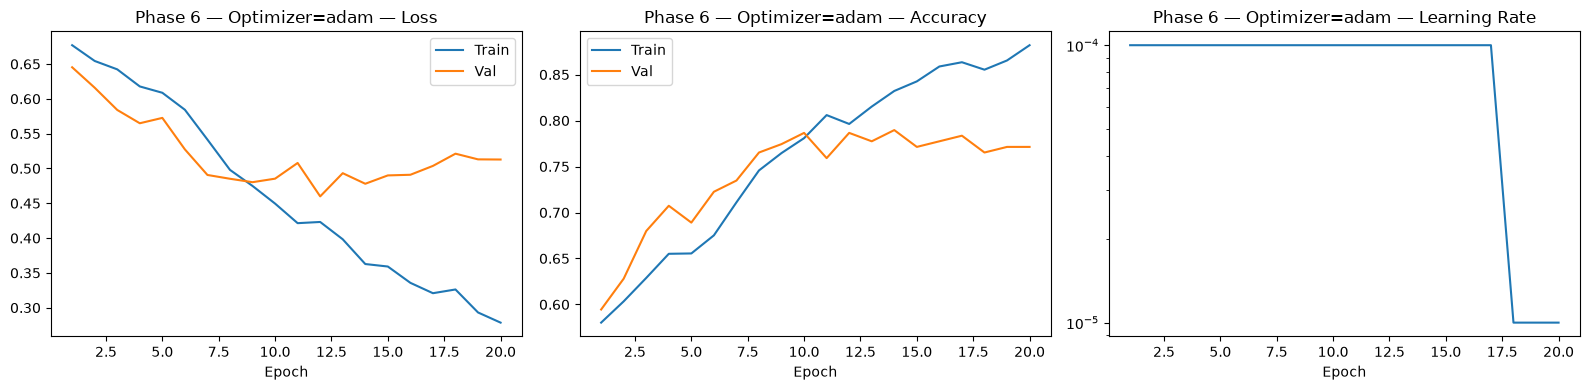


Experiment: phase6_opt_sgd
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=sgd loss=CrossEntropyLoss


  [warmup] epoch  1 | train_loss 0.6890 acc 0.5355 | val_loss 0.6797 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6774 acc 0.5799 | val_loss 0.6750 acc 0.5945


  [warmup] epoch  3 | train_loss 0.6779 acc 0.5818 | val_loss 0.6713 acc 0.5945


  [warmup] epoch  4 | train_loss 0.6727 acc 0.5930 | val_loss 0.6684 acc 0.5945


...

  epoch 36 | train_loss 0.5698 acc 0.6929 | val_loss 0.5604 acc 0.6982 | lr(head) 1.00e-04


  epoch 37 | train_loss 0.5691 acc 0.6952 | val_loss 0.5501 acc 0.7073 | lr(head) 1.00e-04


  epoch 38 | train_loss 0.5596 acc 0.6979 | val_loss 0.5602 acc 0.6829 | lr(head) 1.00e-04


  epoch 39 | train_loss 0.5508 acc 0.7022 | val_loss 0.5572 acc 0.7043 | lr(head) 1.00e-04


  epoch 40 | train_loss 0.5602 acc 0.7106 | val_loss 0.5646 acc 0.6860 | lr(head) 1.00e-04


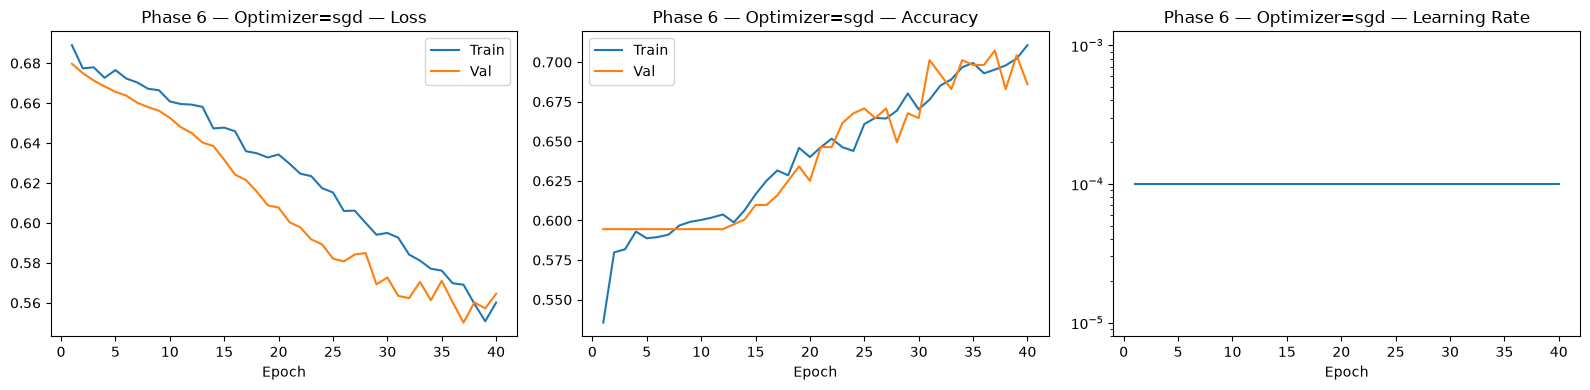

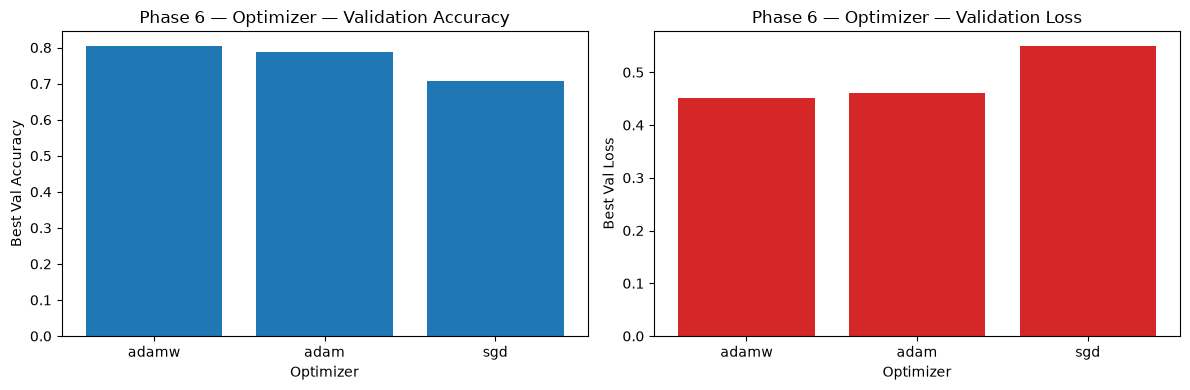

Winner: optimizer=adamw (val_acc=0.8049, val_loss=0.4513)
  removed non-winning checkpoint: checkpoints\phase6_opt_adam.pth
  removed non-winning checkpoint: checkpoints\phase6_opt_sgd.pth


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path
0,phase6_opt_adamw,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1207.4,checkpoints\phase6_opt_adamw.pth
1,phase6_opt_adam,0.0001,0.00001,0.00001,plateau,adam,CrossEntropyLoss,12,20,0.459890,0.786585,1197.4,checkpoints\phase6_opt_adam.pth
2,phase6_opt_sgd,0.0001,0.00001,0.00001,plateau,sgd,CrossEntropyLoss,37,40,0.550102,0.707317,2467.1,checkpoints\phase6_opt_sgd.pth


In [25]:
OPTIMIZER_VARIANTS = ["adamw", "adam", "sgd"]

phase6_results = []
phase6_histories = {}
for opt_name in OPTIMIZER_VARIANTS:
    name = f"phase6_opt_{opt_name}"
    hist, ckpt, row = train_experiment(
        exp_name=name, head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
        weight_decay=BEST_WEIGHT_DECAY, scheduler_name=BEST_SCHEDULER,
        train_loader=train_loader, val_loader=val_loader,
        loss_fn=build_loss(BEST_LOSS), optimizer_name=opt_name,
    )
    phase6_histories[name] = hist
    phase6_results.append(row)
    plot_curves(hist, f"Phase 6 — Optimizer={opt_name}")

phase6_df = pd.DataFrame(phase6_results)
plot_phase_comparison(phase6_df, "optimizer", "Optimizer", "Phase 6 — Optimizer", categorical=True)

best_opt_row = select_best_variant(phase6_df)
BEST_OPTIMIZER = best_opt_row["optimizer"]
print(f"Winner: optimizer={BEST_OPTIMIZER} "
      f"(val_acc={best_opt_row['best_val_accuracy']:.4f}, val_loss={best_opt_row['best_val_loss']:.4f})")

keep_only_best_checkpoint(phase6_results, best_opt_row["experiment"])
all_phase_results.append(best_opt_row.to_dict())
phase6_df


## Summary of winning hyperparameters

In [26]:
best_hparams = {
    "head_lr": BEST_HEAD_LR,
    "backbone_lr": BEST_BACKBONE_LR,
    "weight_decay": BEST_WEIGHT_DECAY,
    "scheduler": BEST_SCHEDULER,
    "augmentation": BEST_AUGMENTATION,
    "loss": BEST_LOSS,
    "optimizer": BEST_OPTIMIZER,
}
print(json.dumps(best_hparams, indent=2, default=str))

with open(os.path.join(RESULTS_DIR, "best_hyperparameters.json"), "w") as f:
    json.dump(best_hparams, f, indent=2, default=str)

phase_summary_df = pd.DataFrame(all_phase_results)
phase_summary_df.to_csv(os.path.join(RESULTS_DIR, "phase_winners_summary.csv"), index=False)
phase_summary_df


{
  "head_lr": 0.0001,
  "backbone_lr": 1e-05,
  "weight_decay": 1e-05,
  "scheduler": "plateau",
  "augmentation": "baseline",
  "loss": "ce_unweighted",
  "optimizer": "adamw"
}


,experiment,head_lr,backbone_lr,weight_decay,scheduler,optimizer,loss,best_epoch,epochs_run,best_val_loss,best_val_accuracy,training_time_sec,checkpoint_path,augmentation,loss_variant
0,phase1_lr_1e-04,0.0001,0.00001,0.00010,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1051.8,checkpoints\phase1_lr_1e-04.pth,NaN,NaN
1,phase2_wd_1e-05,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1453.9,checkpoints\phase2_wd_1e-05.pth,NaN,NaN
2,phase3_sched_plateau,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1171.6,checkpoints\phase3_sched_plateau.pth,NaN,NaN
3,phase4_aug_baseline,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1405.6,checkpoints\phase4_aug_baseline.pth,baseline,NaN
4,phase5_loss_ce_unweighted,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,925.4,checkpoints\phase5_loss_ce_unweighted.pth,NaN,ce_unweighted
5,phase6_opt_adamw,0.0001,0.00001,0.00001,plateau,adamw,CrossEntropyLoss,12,20,0.451265,0.804878,1207.4,checkpoints\phase6_opt_adamw.pth,NaN,NaN


## Final Run — Combined Optimal Hyperparameters

Trains one last model from fresh ImageNet weights using every winning value found above together,
then evaluates it on the held-out **test set**.

In [11]:
final_train_loader, final_val_loader, final_test_loader = make_loaders(TRANSFORM_VARIANTS[BEST_AUGMENTATION])

final_history, final_ckpt, final_row = train_experiment(
    exp_name="final_combined_optimal",
    head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
    weight_decay=BEST_WEIGHT_DECAY, scheduler_name=BEST_SCHEDULER,
    train_loader=final_train_loader, val_loader=final_val_loader,
    loss_fn=build_loss(BEST_LOSS), optimizer_name=BEST_OPTIMIZER,
)
plot_curves(final_history, "Final — Combined Optimal Hyperparameters")

final_test_eval = evaluate_checkpoint(final_row["checkpoint_path"], final_test_loader, tag="final-test")
print(final_test_eval["report"])


NameError: name 'BEST_AUGMENTATION' is not defined

In [ ]:
final_train_loader, final_val_loader, final_test_loader = make_loaders(TRANSFORM_VARIANTS[BEST_AUGMENTATION])

final_history, final_ckpt, final_row = train_experiment(
    exp_name="final_combined_optimal",
    head_lr=BEST_HEAD_LR, backbone_lr=BEST_BACKBONE_LR,
    weight_decay=BEST_WEIGHT_DECAY, scheduler_name=BEST_SCHEDULER,
    train_loader=final_train_loader, val_loader=final_val_loader,
    loss_fn=build_loss(BEST_LOSS), optimizer_name=BEST_OPTIMIZER,
)
plot_curves(final_history, "Final — Combined Optimal Hyperparameters")

final_test_eval = evaluate_checkpoint(final_row["checkpoint_path"], final_test_loader, tag="final-test")
print(final_test_eval["report"])


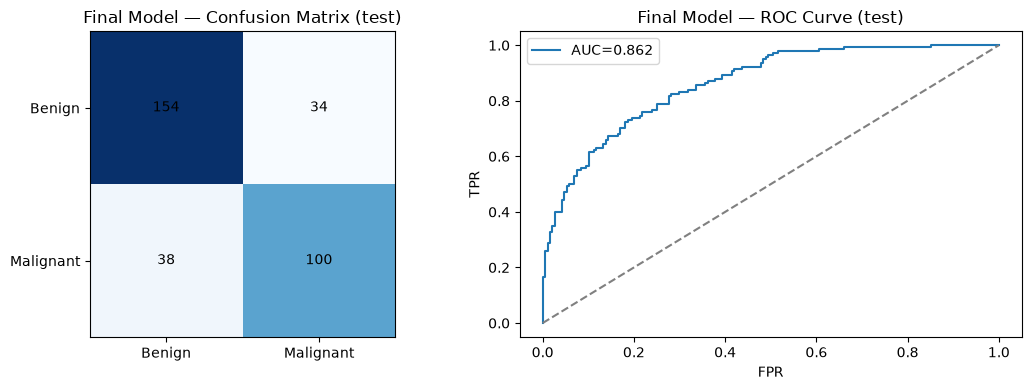

In [28]:
# --- Final confusion matrix + ROC curve (test set) ---
cm = final_test_eval["confusion_matrix"]
labels, probs = final_test_eval["labels"], final_test_eval["probs"]
fpr, tpr, _ = roc_curve(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Final Model — Confusion Matrix (test)")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center")

axes[1].plot(fpr, tpr, label=f"AUC={final_test_eval['metrics']['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Final Model — ROC Curve (test)"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()
plt.tight_layout(); plt.show()


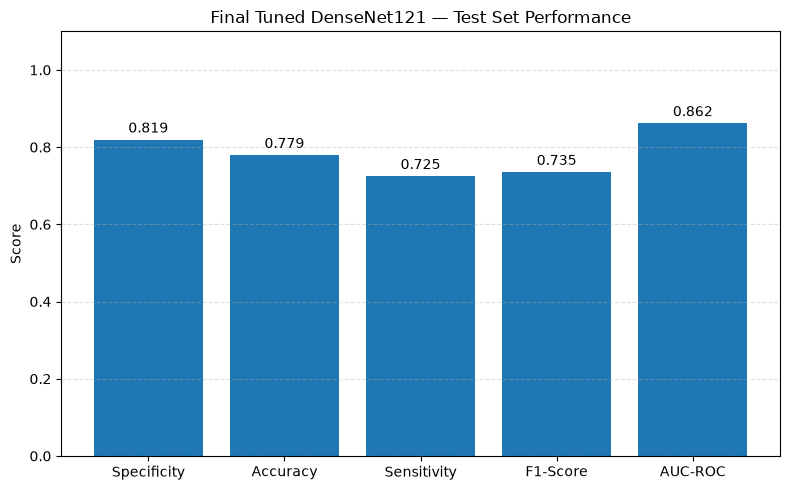

,model,head_lr,backbone_lr,weight_decay,scheduler,augmentation,loss,optimizer,accuracy,sensitivity,specificity,f1,roc_auc,best_val_accuracy,checkpoint_path
0,DenseNet121 (tuned),0.0001,0.00001,0.00001,plateau,baseline,ce_unweighted,adamw,0.779141,0.724638,0.819149,0.735294,0.861702,0.804878,checkpoints\final_combined_optimal.pth


In [29]:
# --- Final metrics bar chart: Specificity, Accuracy, Sensitivity, F1-Score, AUC-ROC ---
metric_cols = ["specificity", "accuracy", "sensitivity", "f1", "roc_auc"]
metric_labels = ["Specificity", "Accuracy", "Sensitivity", "F1-Score", "AUC-ROC"]
values = [final_test_eval["metrics"][c] for c in metric_cols]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metric_labels, values, color="tab:blue")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", va="bottom")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Final Tuned DenseNet121 — Test Set Performance")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "final_model_test_metrics.png"), dpi=200, bbox_inches="tight")
plt.show()

final_results_row = {"model": "DenseNet121 (tuned)", **best_hparams, **final_test_eval["metrics"],
                      "best_val_accuracy": final_row["best_val_accuracy"],
                      "checkpoint_path": final_row["checkpoint_path"]}
final_results_df = pd.DataFrame([final_results_row])
final_results_df.to_csv(os.path.join(RESULTS_DIR, "final_model_results.csv"), index=False)
final_results_df


In [30]:
# --- Regularized dual-input model: adjustable dropout, smaller head, partial backbone freezing ---
def _set_partial_trainable(extractor, unfreeze_from_block):
    """Freezes every child of the DenseNet `features` module up to (not including)
    `unfreeze_from_block`, then unfreezes everything from that block onward."""
    features_module = extractor[0]  # base.features (Sequential of conv0/denseblock1/.../norm5)
    unfreezing = False
    for name, module in features_module.named_children():
        if name == unfreeze_from_block:
            unfreezing = True
        for p in module.parameters():
            p.requires_grad = unfreezing
        module.train(unfreezing)


class DualInputDenseNetReg(nn.Module):
    """Same design as DualInputDenseNet, but with configurable dropout, configurable classifier
    width, and support for partial (rather than all-or-nothing) backbone unfreezing."""

    DENSE_BLOCKS = ["denseblock1", "denseblock2", "denseblock3", "denseblock4"]

    def __init__(self, num_classes=2, dropout=0.6, hidden_dims=(256, 64)):
        super().__init__()
        self.full_extractor, feat_dim_full = build_densenet_backbone()
        self.crop_extractor, feat_dim_crop = build_densenet_backbone()
        combined_dim = feat_dim_full + feat_dim_crop
        h1, h2 = hidden_dims
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, h1), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(h1, h2), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(h2, num_classes),
        )

    def forward(self, full_image, cropped_image):
        full_feat = torch.flatten(self.full_extractor(full_image), 1)
        crop_feat = torch.flatten(self.crop_extractor(cropped_image), 1)
        combined = torch.cat([full_feat, crop_feat], dim=1)
        return self.classifier(combined)

    def set_backbones_trainable(self, trainable: bool):
        """Full freeze/unfreeze — used for the Phase 1-style head warmup."""
        for extractor in (self.full_extractor, self.crop_extractor):
            for p in extractor.parameters():
                p.requires_grad = trainable
            extractor.train(trainable)

    def set_partial_backbone_trainable(self, unfreeze_last_n_blocks=2):
        """Unfreezes only the last `unfreeze_last_n_blocks` dense blocks (+ everything after
        them, e.g. norm5) in each backbone; earlier blocks stay frozen at ImageNet weights."""
        unfreeze_from = self.DENSE_BLOCKS[-unfreeze_last_n_blocks]
        for extractor in (self.full_extractor, self.crop_extractor):
            _set_partial_trainable(extractor, unfreeze_from)
        return unfreeze_from


In [31]:
# --- Trainer variant: same two-phase procedure, but with configurable dropout/head width/
#     partial unfreezing/early-stopping patience ---
def train_experiment_regularized(exp_name, head_lr, backbone_lr, weight_decay, scheduler_name,
                                  train_loader, val_loader, loss_fn=None, optimizer_name="adamw",
                                  dropout=0.65, hidden_dims=(256, 64), unfreeze_last_n_blocks=2,
                                  patience=5, max_epochs=MAX_EPOCHS):
    set_seed(SEED)
    criterion = loss_fn if loss_fn is not None else nn.CrossEntropyLoss()
    print(f"\n{'='*80}\nExperiment: {exp_name}\n"
          f"head_lr={head_lr} backbone_lr={backbone_lr} weight_decay={weight_decay} "
          f"scheduler={scheduler_name} optimizer={optimizer_name} loss={type(criterion).__name__}\n"
          f"dropout={dropout} hidden_dims={hidden_dims} unfreeze_last_n_blocks={unfreeze_last_n_blocks} "
          f"patience={patience}\n{'='*80}")

    model = DualInputDenseNetReg(dropout=dropout, hidden_dims=hidden_dims).to(DEVICE)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt_path = os.path.join(CKPT_DIR, f"{exp_name}.pth")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss, best_val_acc, global_epoch = float("inf"), 0.0, 0
    start_time = time.time()

    # ---- Phase 1: head warmup, backbones fully frozen (same as every other experiment) ----
    model.set_backbones_trainable(False)
    optimizer = build_optimizer(
        optimizer_name,
        [{"params": filter(lambda p: p.requires_grad, model.parameters()), "lr": head_lr}],
        weight_decay,
    )
    for _ in range(min(HEAD_WARMUP_EPOCHS, max_epochs)):
        global_epoch += 1
        tr_loss, tr_m, _ = run_epoch(model, train_loader, DEVICE, criterion, optimizer, scaler, use_amp,
                                      desc=f"{exp_name} e{global_epoch} [warmup-train]")
        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [warmup-val]")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"  [warmup] epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_val_acc = va_loss, va_m["accuracy"]
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "val_accuracy": float(va_m["accuracy"]), "val_loss": float(va_loss)}, ckpt_path)

    # ---- Phase 2: PARTIAL unfreeze (only the last N dense blocks), discriminative LR ----
    unfrozen_from = model.set_partial_backbone_trainable(unfreeze_last_n_blocks)
    print(f"  Unfroze backbone from '{unfrozen_from}' onward; earlier blocks stay frozen.")
    optimizer = build_optimizer(
        optimizer_name,
        [
            {"params": filter(lambda p: p.requires_grad, model.full_extractor.parameters()), "lr": backbone_lr},
            {"params": filter(lambda p: p.requires_grad, model.crop_extractor.parameters()), "lr": backbone_lr},
            {"params": model.classifier.parameters(), "lr": head_lr},
        ],
        weight_decay,
    )

    remaining_epochs = max(max_epochs - HEAD_WARMUP_EPOCHS, 0)
    scheduler, step_mode = build_scheduler(scheduler_name, optimizer,
                                            steps_per_epoch=len(train_loader), total_epochs=max(remaining_epochs, 1))
    epochs_no_improve = 0

    for _ in range(remaining_epochs):
        global_epoch += 1
        model.train()
        running_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
        for full_imgs, crop_imgs, labels in tqdm(train_loader, desc=f"{exp_name} e{global_epoch} [train]", leave=False):
            full_imgs = full_imgs.to(DEVICE, non_blocking=True)
            crop_imgs = crop_imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if step_mode == "batch":
                scheduler.step()
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
        tr_loss = running_loss / len(train_loader.dataset)
        tr_m = compute_metrics(all_labels, all_preds, all_probs)

        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [val]")
        if step_mode == "epoch":
            if scheduler_name == "plateau":
                scheduler.step(va_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[-1]["lr"])
        print(f"  epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f} | lr(head) {optimizer.param_groups[-1]['lr']:.2e}")

        if va_loss < best_val_loss:
            best_val_loss, best_val_acc, epochs_no_improve = va_loss, va_m["accuracy"], 0
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_accuracy": float(va_m["accuracy"]), "val_loss": float(va_loss)}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {global_epoch}.")
                break

    elapsed = time.time() - start_time
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    del model
    free_gpu()

    result_row = {
        "experiment": exp_name, "head_lr": head_lr, "backbone_lr": backbone_lr,
        "weight_decay": weight_decay, "scheduler": scheduler_name, "optimizer": optimizer_name,
        "loss": type(criterion).__name__, "dropout": dropout, "hidden_dims": hidden_dims,
        "unfreeze_last_n_blocks": unfreeze_last_n_blocks, "patience": patience,
        "best_epoch": checkpoint["epoch"] + 1, "epochs_run": global_epoch,
        "best_val_loss": checkpoint["val_loss"], "best_val_accuracy": checkpoint["val_accuracy"],
        "training_time_sec": round(elapsed, 1), "checkpoint_path": ckpt_path,
    }
    return history, checkpoint, result_row


def evaluate_checkpoint_reg(ckpt_path, loader, dropout=0.65, hidden_dims=(256, 64), tag=""):
    """Same as evaluate_checkpoint, but rebuilds a DualInputDenseNetReg (regularized model)
    with matching architecture before loading weights."""
    model = DualInputDenseNetReg(dropout=dropout, hidden_dims=hidden_dims).to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=f"eval {tag}", leave=False):
            full_imgs, crop_imgs = full_imgs.to(DEVICE), crop_imgs.to(DEVICE)
            outputs = model(full_imgs, crop_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    del model
    free_gpu()
    return {"metrics": metrics, "confusion_matrix": cm, "report": report,
            "labels": all_labels, "preds": all_preds, "probs": all_probs}



Experiment: followup_regularized
head_lr=0.0001 backbone_lr=1e-05 weight_decay=1e-05 scheduler=plateau optimizer=adamw loss=CrossEntropyLoss
dropout=0.65 hidden_dims=(256, 64) unfreeze_last_n_blocks=2 patience=5


  [warmup] epoch  1 | train_loss 0.6823 acc 0.5637 | val_loss 0.6664 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6759 acc 0.5748 | val_loss 0.6552 acc 0.5945


  [warmup] epoch  3 | train_loss 0.6699 acc 0.5876 | val_loss 0.6518 acc 0.5945


  [warmup] epoch  4 | train_loss 0.6678 acc 0.5961 | val_loss 0.6403 acc 0.5945


...

  epoch 15 | train_loss 0.4253 acc 0.8067 | val_loss 0.5309 acc 0.7348 | lr(head) 1.00e-04


  epoch 16 | train_loss 0.4157 acc 0.8075 | val_loss 0.5253 acc 0.7256 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.4011 acc 0.8225 | val_loss 0.5623 acc 0.7378 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3934 acc 0.8218 | val_loss 0.5338 acc 0.7470 | lr(head) 1.00e-04


  epoch 19 | train_loss 0.3806 acc 0.8318 | val_loss 0.5290 acc 0.7622 | lr(head) 1.00e-04
  Early stopping at epoch 19.


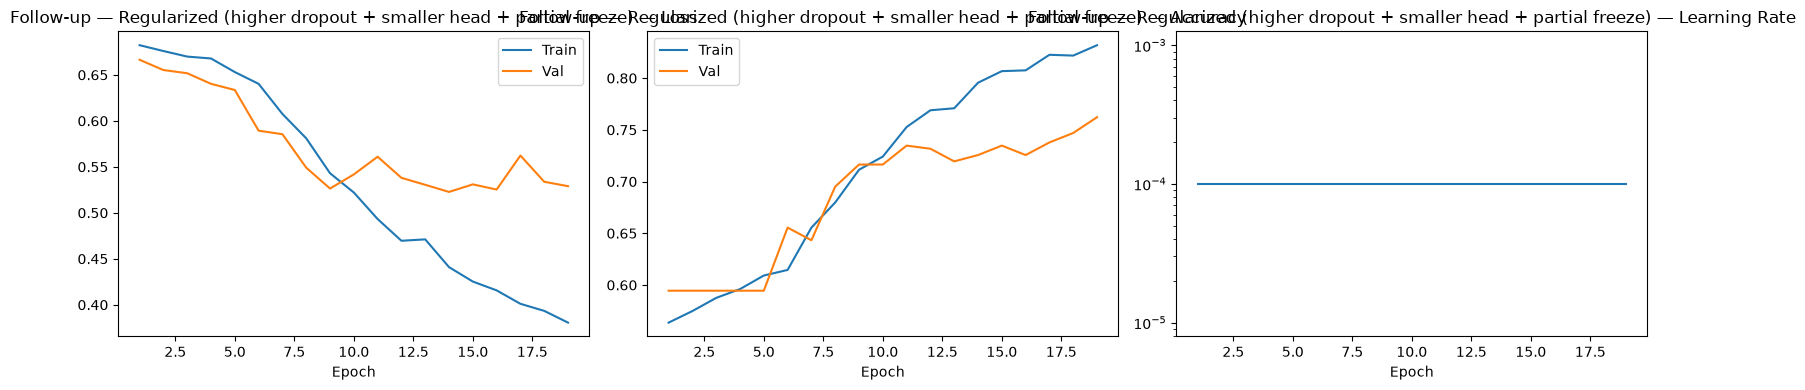

              precision    recall  f1-score   support

      Benign       0.78      0.75      0.77       188
   Malignant       0.68      0.72      0.70       138

    accuracy                           0.74       326
   macro avg       0.73      0.73      0.73       326
weighted avg       0.74      0.74      0.74       326



In [ ]:
# Disabled: the regularized follow-up experiment is no longer part of the active workflow.
print("Regularized follow-up is disabled in this notebook version.")


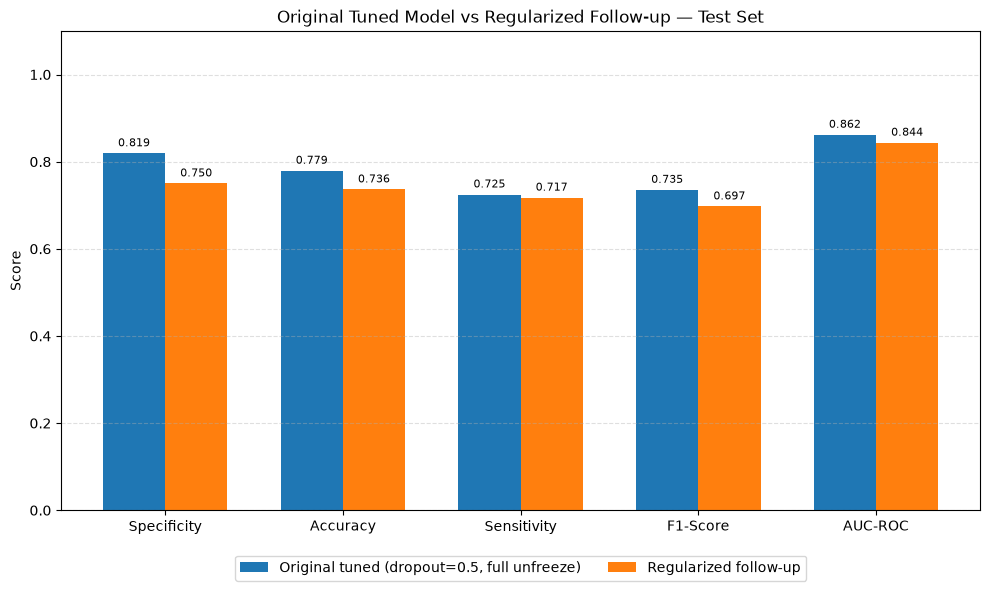

,model,accuracy,sensitivity,specificity,f1,roc_auc,best_val_accuracy
0,Original tuned,0.779141,0.724638,0.819149,0.735294,0.861702,0.804878
1,Regularized follow-up,0.736196,0.717391,0.750000,0.697183,0.843509,0.725610


In [ ]:
# Disabled: the regularized follow-up comparison is not part of the active workflow.
print("Regularized follow-up comparison is disabled in this notebook version.")


In [ ]:
# Disabled: the regularized follow-up diagnostics and optional ablations are no longer part of the active workflow.
print("Regularized follow-up diagnostics are disabled in this notebook version.")


                   run  best_val_loss_epoch  best_val_loss  val_acc_at_best_loss  train_acc_at_best_loss  gap_at_best_loss  best_val_acc_epoch  best_val_acc  train_acc_at_best_acc  val_loss_at_best_acc  gap_at_best_acc
final_combined_optimal                   12       0.451265              0.804878                0.804012         -0.000866                  12      0.804878               0.804012              0.451265        -0.000866
  regularized_followup                   14       0.522711              0.725610                0.795525          0.069915                  19      0.762195               0.831790              0.528966         0.069595

Interpretation:
- If the best-val-accuracy epoch differs from the best-val-loss epoch, the current checkpoint rule may be leaving accuracy on the table.
- The follow-up run underperformed the original tuned model, so heavier dropout and partial freezing alone are not the missing ingredient.
- Train/val gap widening late in training is the c

## Post-hoc Improvement — TTA Only

The notebook keeps the original tuned model and applies test-time augmentation only.
The regularized follow-up and threshold-tuning sections below are intentionally disabled.

The TTA path uses the already-trained `final_combined_optimal` checkpoint and does not create
new weights; the new cell below saves a named copy of that checkpoint for the TTA-only artifact.

In [12]:
# --- TTA infrastructure ---
from torchvision.transforms import functional as TF

TTA_VARIANTS = {
    "original": transforms.Compose([
        transforms.ToTensor(), transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "hflip": transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "rotate_pos7": transforms.Compose([
        transforms.Lambda(lambda img: TF.rotate(img, 7)),
        transforms.ToTensor(), transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "rotate_neg7": transforms.Compose([
        transforms.Lambda(lambda img: TF.rotate(img, -7)),
        transforms.ToTensor(), transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
}


def get_tta_probs(ckpt_path, dataframe, variants=TTA_VARIANTS, batch_size=BATCH_SIZE):
    """Runs the model once per TTA variant over `dataframe` and returns
    (labels, averaged_probs, per_variant_probs_dict)."""
    model = DualInputDenseNet().to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    per_variant_probs = {}
    labels_ref = None
    with torch.no_grad():
        for variant_name, tform in variants.items():
            loader = DataLoader(
                DualImageDataset(dataframe, tform), batch_size=batch_size,
                shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
            )
            variant_probs, variant_labels = [], []
            for full_imgs, crop_imgs, labels in tqdm(loader, desc=f"TTA[{variant_name}]", leave=False):
                full_imgs, crop_imgs = full_imgs.to(DEVICE), crop_imgs.to(DEVICE)
                outputs = model(full_imgs, crop_imgs)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                variant_probs.extend(probs.cpu().numpy())
                variant_labels.extend(labels.numpy())
            per_variant_probs[variant_name] = np.array(variant_probs)
            if labels_ref is None:
                labels_ref = np.array(variant_labels)

    del model
    free_gpu()
    avg_probs = np.mean(list(per_variant_probs.values()), axis=0)
    return labels_ref, avg_probs, per_variant_probs


def metrics_at_threshold(labels, probs, threshold):
    preds = (np.asarray(probs) >= threshold).astype(int)
    return compute_metrics(labels, preds, probs)


In [13]:
# Disabled: threshold tuning is not part of the active workflow.
print("Threshold tuning is disabled in this notebook version.")


Threshold tuning is disabled in this notebook version.


In [ ]:
# Disabled: the threshold-tuned test evaluation is not part of the active workflow.
print("Threshold-tuned test evaluation is disabled in this notebook version.")


No TTA, default threshold (original result):
{'accuracy': 0.7791, 'sensitivity': 0.7246, 'specificity': np.float64(0.8191), 'f1': 0.7353, 'roc_auc': 0.8617}

TTA (4-view avg), default 0.50 threshold:
{'accuracy': 0.7822, 'sensitivity': 0.7319, 'specificity': np.float64(0.8191), 'f1': 0.7399, 'roc_auc': 0.8697}

TTA (4-view avg), tuned threshold (0.56):
{'accuracy': 0.7822, 'sensitivity': 0.6957, 'specificity': np.float64(0.8457), 'f1': 0.73, 'roc_auc': 0.8697}


In [14]:
# --- 2-way comparison: original vs TTA-only (test set) ---
metric_cols = ["specificity", "accuracy", "sensitivity", "f1", "roc_auc"]
metric_labels = ["Specificity", "Accuracy", "Sensitivity", "F1-Score", "AUC-ROC"]

ORIGINAL_CKPT_PATH = final_row["checkpoint_path"]
test_labels_tta, test_probs_tta, per_variant_test_probs = get_tta_probs(ORIGINAL_CKPT_PATH, test_df, TTA_VARIANTS)
tta_only_metrics = metrics_at_threshold(test_labels_tta, test_probs_tta, 0.5)

series = {
    "Original (no TTA, 0.50)": [final_test_eval["metrics"][c] for c in metric_cols],
    "TTA only (0.50)": [tta_only_metrics[c] for c in metric_cols],
}

x = np.arange(len(metric_cols))
n_series = len(series)
width = 0.8 / n_series
colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (label, values) in enumerate(series.items()):
    offset = (i - (n_series - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, label=label, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Original vs TTA Only — Test Set")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tta_only_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

tta_comparison_df = pd.DataFrame([
    {"variant": "original", "threshold": 0.50, **final_test_eval["metrics"]},
    {"variant": "tta_only", "threshold": 0.50, **tta_only_metrics},
])
tta_comparison_df.to_csv(os.path.join(RESULTS_DIR, "tta_only_comparison.csv"), index=False)
tta_comparison_df


NameError: name 'final_row' is not defined

In [ ]:
# Save a dedicated TTA-only checkpoint copy for the already-trained tuned model.
# TTA changes inference behavior, not the learned weights, so this preserves the same state_dict.
import shutil

FINAL_CHECKPOINT_PATH = os.path.join(CKPT_DIR, "final_combined_optimal.pth")
TTA_ONLY_CHECKPOINT_PATH = os.path.join(RESULTS_DIR, "tta_only_final_combined_optimal.pth")
shutil.copy2(FINAL_CHECKPOINT_PATH, TTA_ONLY_CHECKPOINT_PATH)

tta_only_manifest = {
    "variant": "tta_only",
    "source_checkpoint": FINAL_CHECKPOINT_PATH,
    "saved_checkpoint": TTA_ONLY_CHECKPOINT_PATH,
}
with open(os.path.join(RESULTS_DIR, "tta_only_checkpoint_manifest.json"), "w") as f:
    json.dump(tta_only_manifest, f, indent=2)

print(f"Saved TTA-only checkpoint copy to {TTA_ONLY_CHECKPOINT_PATH}")

Saved TTA-only checkpoint copy to results\tta_only_final_combined_optimal.pth


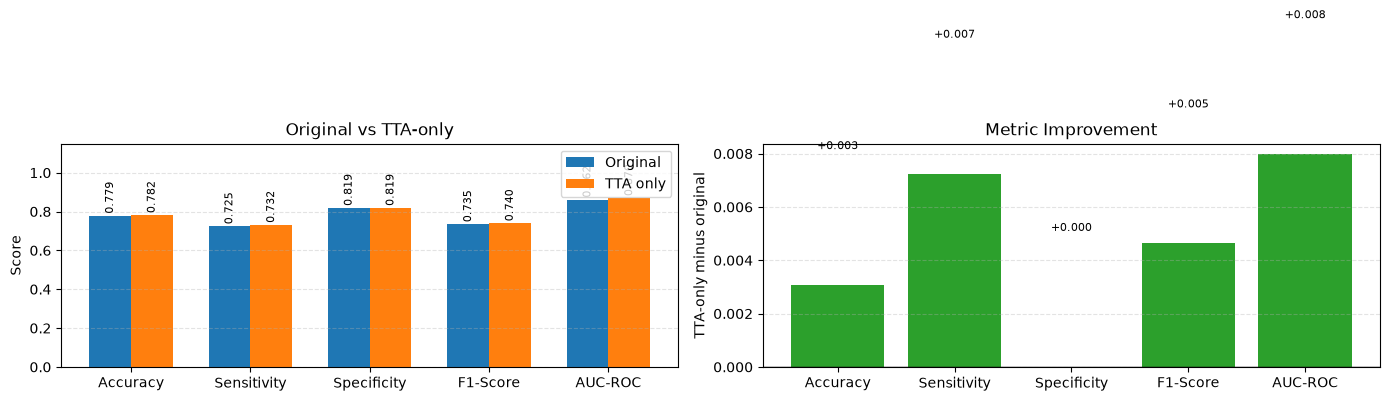

,metric,original,tta_only,delta
0,Accuracy,0.779141,0.782209,0.003067
1,Sensitivity,0.724638,0.731884,0.007246
2,Specificity,0.819149,0.819149,0.000000
3,F1-Score,0.735294,0.739927,0.004633
4,AUC-ROC,0.861702,0.869681,0.007979


In [17]:
# Visual report: original model vs TTA-only using the saved comparison CSV.
comparison_df = pd.read_csv(os.path.join(RESULTS_DIR, "tta_threshold_comparison.csv"))
report_df = comparison_df.set_index("variant").loc[["original", "tta_only"]]

metric_cols = ["accuracy", "sensitivity", "specificity", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Sensitivity", "Specificity", "F1-Score", "AUC-ROC"]
original_values = report_df.loc["original", metric_cols].astype(float).to_numpy()
tta_values = report_df.loc["tta_only", metric_cols].astype(float).to_numpy()
delta_values = tta_values - original_values

x = np.arange(len(metric_cols))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars1 = axes[0].bar(x - width / 2, original_values, width, label="Original", color="tab:blue")
bars2 = axes[0].bar(x + width / 2, tta_values, width, label="TTA only", color="tab:orange")
for bars in (bars1, bars2):
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].set_title("Original vs TTA-only")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.35)

delta_bars = axes[1].bar(metric_labels, delta_values, color=["tab:green" if v >= 0 else "tab:red" for v in delta_values])
axes[1].axhline(0, color="black", linewidth=1)
for bar, val in zip(delta_bars, delta_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + (0.005 if val >= 0 else -0.02),
                 f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)
axes[1].set_ylabel("TTA-only minus original")
axes[1].set_title("Metric Improvement")
axes[1].grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tta_only_visual_report.png"), dpi=200, bbox_inches="tight")
plt.show()

report_summary = pd.DataFrame({
    "metric": metric_labels,
    "original": original_values,
    "tta_only": tta_values,
    "delta": delta_values,
})
report_summary

In [18]:
report_summary.to_csv('original_tta_comparison.csv', index=False)

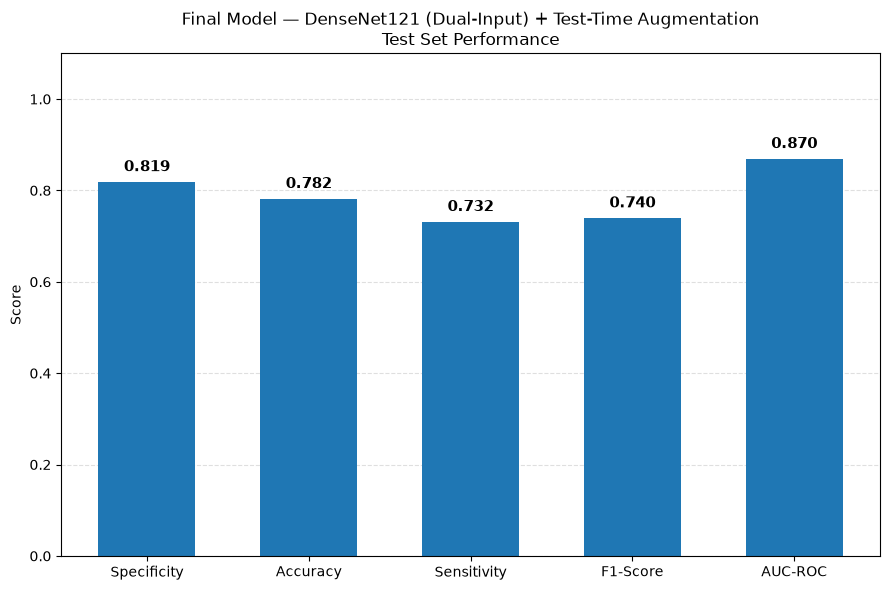

,metric,score
0,Specificity,0.819149
1,Accuracy,0.782209
2,Sensitivity,0.731884
3,F1-Score,0.739927
4,AUC-ROC,0.869681


In [19]:
# Final model report: DenseNet121 (dual-input) + 4-view TTA — Specificity, Accuracy, Sensitivity, F1-Score, AUC-ROC
comparison_df = pd.read_csv(os.path.join(RESULTS_DIR, "tta_threshold_comparison.csv"))
final_row_metrics = comparison_df.set_index("variant").loc["tta_only"]

metric_cols = ["specificity", "accuracy", "sensitivity", "f1", "roc_auc"]
metric_labels = ["Specificity", "Accuracy", "Sensitivity", "F1-Score", "AUC-ROC"]
final_values = final_row_metrics[metric_cols].astype(float).to_numpy()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(metric_labels, final_values, color="tab:blue", width=0.6)
for bar, val in zip(bars, final_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Final Model — DenseNet121 (Dual-Input) + Test-Time Augmentation\nTest Set Performance")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "final_model_report.png"), dpi=200, bbox_inches="tight")
plt.show()

final_model_summary = pd.DataFrame({
    "metric": metric_labels,
    "score": final_values,
})
final_model_summary